In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from dysts.systems import get_attractor_list
from dysts.flows import __dict__ as flow_models
from dysts.analysis import gp_dim
from dysts.metrics import estimate_kl_divergence
import os

In [2]:
granularity = 30
forecast_length = 300

context_lengths_chronos = 2**np.arange(6, 11)

context_lengths_parrot = 2**np.arange(6, 17)

context_lengths_TimesFM = 2**np.arange(6, 13)

context_lengths_TimeMoE = 2**np.arange(6, 14)

# Directory to store trajectories
#trajectory_dir = "trajectories"
trajectory_dir = "long_trajectories"
os.makedirs(trajectory_dir, exist_ok=True)

equation_names = get_attractor_list()
equation_names.remove('FluidTrampoline')
equation_names.remove('HyperLu')
equation_names.remove('SprottMore')
equation_names.remove('StickSlipOscillator')
#equation_names = equation_names[:2]

In [4]:
Parrot_average_vpt = np.load(f'./parrot_statistics_normalized/D=10_average_vpt.npy',allow_pickle='TRUE').item()
Parrot_median_vpt = np.load(f'./parrot_statistics_normalized/D=10_median_vpt.npy',allow_pickle='TRUE').item()
#Parrot_average_l2 = np.load(f'./parrot_statistics_normalized/D=10_average_l2.npy',allow_pickle='TRUE').item()
#Parrot_median_l2 = np.load(f'./parrot_statistics_normalized/D=10_median_l2.npy',allow_pickle='TRUE').item()
Parrot_average_smape = np.load(f'./parrot_statistics_normalized/D=10_average_smape.npy',allow_pickle='TRUE').item()
Parrot_median_smape = np.load(f'./parrot_statistics_normalized/D=10_median_smape.npy',allow_pickle='TRUE').item()
Parrot_average_cdim = np.load(f'./parrot_statistics_normalized/D=10_average_cdim.npy',allow_pickle='TRUE').item()
Parrot_median_cdim = np.load(f'./parrot_statistics_normalized/D=10_median_cdim.npy',allow_pickle='TRUE').item()
Parrot_average_kl = np.load(f'./parrot_statistics_normalized/D=10_average_kl.npy',allow_pickle='TRUE').item()
Parrot_median_kl = np.load(f'./parrot_statistics_normalized/D=10_median_kl.npy',allow_pickle='TRUE').item()
Parrot_average_vpt_2 = np.load(f'./parrot_statistics_normalized/D=10_average_vpt_2.npy',allow_pickle='TRUE').item()
Parrot_median_vpt_2 = np.load(f'./parrot_statistics_normalized/D=10_median_vpt_2.npy',allow_pickle='TRUE').item()
Parrot_average_smape_2 = np.load(f'./parrot_statistics_normalized/D=10_average_smape_2.npy',allow_pickle='TRUE').item()
Parrot_median_smape_2 = np.load(f'./parrot_statistics_normalized/D=10_median_smape_2.npy',allow_pickle='TRUE').item()
Parrot_average_cpu_cost = np.load(f'./parrot_statistics_normalized/D=10_average_cpu_cost.npy',allow_pickle='TRUE').item()
Parrot_median_cpu_cost = np.load(f'./parrot_statistics_normalized/D=10_median_cpu_cost.npy',allow_pickle='TRUE').item()
Parrot_average_wall_cost = np.load(f'./parrot_statistics_normalized/D=10_average_wall_cost.npy',allow_pickle='TRUE').item()
Parrot_median_wall_cost = np.load(f'./parrot_statistics_normalized/D=10_median_wall_cost.npy',allow_pickle='TRUE').item()
Parrot_average_mse = np.load(f'./parrot_statistics_normalized/D=10_average_mse.npy',allow_pickle='TRUE').item()
Parrot_median_mse = np.load(f'./parrot_statistics_normalized/D=10_median_mse.npy',allow_pickle='TRUE').item()
Parrot_average_mae = np.load(f'./parrot_statistics_normalized/D=10_average_mae.npy',allow_pickle='TRUE').item()
Parrot_median_mae = np.load(f'./parrot_statistics_normalized/D=10_median_mae.npy',allow_pickle='TRUE').item()

In [5]:
TimesFM_average_vpt = np.load(f'./TimesFM_statistics_normalized/average_vpt.npy',allow_pickle='TRUE').item()
TimesFM_median_vpt = np.load(f'./TimesFM_statistics_normalized/median_vpt.npy',allow_pickle='TRUE').item()
TimesFM_average_smape = np.load(f'./TimesFM_statistics_normalized/average_smape.npy',allow_pickle='TRUE').item()
TimesFM_median_smape = np.load(f'./TimesFM_statistics_normalized/median_smape.npy',allow_pickle='TRUE').item()
TimesFM_average_cdim = np.load(f'./TimesFM_statistics_normalized/average_cdim.npy',allow_pickle='TRUE').item()
TimesFM_median_cdim = np.load(f'./TimesFM_statistics_normalized/median_cdim.npy',allow_pickle='TRUE').item()
TimesFM_average_kl = np.load(f'./TimesFM_statistics_normalized/average_kl.npy',allow_pickle='TRUE').item()
TimesFM_median_kl = np.load(f'./TimesFM_statistics_normalized/median_kl.npy',allow_pickle='TRUE').item()
TimesFM_average_vpt_2 = np.load(f'./TimesFM_statistics_normalized/average_vpt_2.npy',allow_pickle='TRUE').item()
TimesFM_median_vpt_2 = np.load(f'./TimesFM_statistics_normalized/median_vpt_2.npy',allow_pickle='TRUE').item()
TimesFM_average_smape_2 = np.load(f'./TimesFM_statistics_normalized/average_smape_2.npy',allow_pickle='TRUE').item()
TimesFM_median_smape_2 = np.load(f'./TimesFM_statistics_normalized/median_smape_2.npy',allow_pickle='TRUE').item()
TimesFM_average_cpu_cost = np.load(f'./TimesFM_statistics_normalized/average_cpu_cost.npy',allow_pickle='TRUE').item()
TimesFM_median_cpu_cost = np.load(f'./TimesFM_statistics_normalized/median_cpu_cost.npy',allow_pickle='TRUE').item()
TimesFM_average_wall_cost = np.load(f'./TimesFM_statistics_normalized/average_wall_cost.npy',allow_pickle='TRUE').item()
TimesFM_median_wall_cost = np.load(f'./TimesFM_statistics_normalized/median_wall_cost.npy',allow_pickle='TRUE').item()
TimesFM_average_mse = np.load(f'./TimesFM_statistics_normalized/average_mse.npy',allow_pickle='TRUE').item()
TimesFM_median_mse = np.load(f'./TimesFM_statistics_normalized/median_mse.npy',allow_pickle='TRUE').item()
TimesFM_average_mae = np.load(f'./TimesFM_statistics_normalized/average_mae.npy',allow_pickle='TRUE').item()
TimesFM_median_mae = np.load(f'./TimesFM_statistics_normalized/median_mae.npy',allow_pickle='TRUE').item()

In [6]:
TimeMoE_average_vpt = np.load(f'./TimeMoE_statistics_normalized/average_vpt.npy',allow_pickle='TRUE').item()
TimeMoE_median_vpt = np.load(f'./TimeMoE_statistics_normalized/median_vpt.npy',allow_pickle='TRUE').item()
TimeMoE_average_smape = np.load(f'./TimeMoE_statistics_normalized/average_smape.npy',allow_pickle='TRUE').item()
TimeMoE_median_smape = np.load(f'./TimeMoE_statistics_normalized/median_smape.npy',allow_pickle='TRUE').item()
TimeMoE_average_cdim = np.load(f'./TimeMoE_statistics_normalized/average_cdim.npy',allow_pickle='TRUE').item()
TimeMoE_median_cdim = np.load(f'./TimeMoE_statistics_normalized/median_cdim.npy',allow_pickle='TRUE').item()
TimeMoE_average_kl = np.load(f'./TimeMoE_statistics_normalized/average_kl.npy',allow_pickle='TRUE').item()
TimeMoE_median_kl = np.load(f'./TimeMoE_statistics_normalized/median_kl.npy',allow_pickle='TRUE').item()
TimeMoE_average_vpt_2 = np.load(f'./TimeMoE_statistics_normalized/average_vpt_2.npy',allow_pickle='TRUE').item()
TimeMoE_median_vpt_2 = np.load(f'./TimeMoE_statistics_normalized/median_vpt_2.npy',allow_pickle='TRUE').item()
TimeMoE_average_smape_2 = np.load(f'./TimeMoE_statistics_normalized/average_smape_2.npy',allow_pickle='TRUE').item()
TimeMoE_median_smape_2 = np.load(f'./TimeMoE_statistics_normalized/median_smape_2.npy',allow_pickle='TRUE').item()
TimeMoE_average_cpu_cost = np.load(f'./TimeMoE_statistics_normalized/average_cpu_cost.npy',allow_pickle='TRUE').item()
TimeMoE_median_cpu_cost = np.load(f'./TimeMoE_statistics_normalized/median_cpu_cost.npy',allow_pickle='TRUE').item()
TimeMoE_average_wall_cost = np.load(f'./TimeMoE_statistics_normalized/average_wall_cost.npy',allow_pickle='TRUE').item()
TimeMoE_median_wall_cost = np.load(f'./TimeMoE_statistics_normalized/median_wall_cost.npy',allow_pickle='TRUE').item()
TimeMoE_average_mse = np.load(f'./TimeMoE_statistics_normalized/average_mse.npy',allow_pickle='TRUE').item()
TimeMoE_median_mse = np.load(f'./TimeMoE_statistics_normalized/median_mse.npy',allow_pickle='TRUE').item()
TimeMoE_average_mae = np.load(f'./TimeMoE_statistics_normalized/average_mae.npy',allow_pickle='TRUE').item()
TimeMoE_median_mae = np.load(f'./TimeMoE_statistics_normalized/median_mae.npy',allow_pickle='TRUE').item()

In [7]:
ChronosBolt_average_vpt = np.load(f'./ChronosBolt_statistics_normalized/average_vpt.npy',allow_pickle='TRUE').item()
ChronosBolt_median_vpt = np.load(f'./ChronosBolt_statistics_normalized/median_vpt.npy',allow_pickle='TRUE').item()
ChronosBolt_average_smape = np.load(f'./ChronosBolt_statistics_normalized/average_smape.npy',allow_pickle='TRUE').item()
ChronosBolt_median_smape = np.load(f'./ChronosBolt_statistics_normalized/median_smape.npy',allow_pickle='TRUE').item()
ChronosBolt_average_cdim = np.load(f'./ChronosBolt_statistics_normalized/average_cdim.npy',allow_pickle='TRUE').item()
ChronosBolt_median_cdim = np.load(f'./ChronosBolt_statistics_normalized/median_cdim.npy',allow_pickle='TRUE').item()
ChronosBolt_average_kl = np.load(f'./ChronosBolt_statistics_normalized/average_kl.npy',allow_pickle='TRUE').item()
ChronosBolt_median_kl = np.load(f'./ChronosBolt_statistics_normalized/median_kl.npy',allow_pickle='TRUE').item()
ChronosBolt_average_vpt_2 = np.load(f'./ChronosBolt_statistics_normalized/average_vpt_2.npy',allow_pickle='TRUE').item()
ChronosBolt_median_vpt_2 = np.load(f'./ChronosBolt_statistics_normalized/median_vpt_2.npy',allow_pickle='TRUE').item()
ChronosBolt_average_smape_2 = np.load(f'./ChronosBolt_statistics_normalized/average_smape_2.npy',allow_pickle='TRUE').item()
ChronosBolt_median_smape_2 = np.load(f'./ChronosBolt_statistics_normalized/median_smape_2.npy',allow_pickle='TRUE').item()
ChronosBolt_average_cpu_cost = np.load(f'./ChronosBolt_statistics_normalized/average_cpu_cost.npy',allow_pickle='TRUE').item()
ChronosBolt_median_cpu_cost = np.load(f'./ChronosBolt_statistics_normalized/median_cpu_cost.npy',allow_pickle='TRUE').item()
ChronosBolt_average_wall_cost = np.load(f'./ChronosBolt_statistics_normalized/average_wall_cost.npy',allow_pickle='TRUE').item()
ChronosBolt_median_wall_cost = np.load(f'./ChronosBolt_statistics_normalized/median_wall_cost.npy',allow_pickle='TRUE').item()
ChronosBolt_average_mse = np.load(f'./ChronosBolt_statistics_normalized/average_mse.npy',allow_pickle='TRUE').item()
ChronosBolt_median_mse = np.load(f'./ChronosBolt_statistics_normalized/median_mse.npy',allow_pickle='TRUE').item()
ChronosBolt_average_mae = np.load(f'./ChronosBolt_statistics_normalized/average_mae.npy',allow_pickle='TRUE').item()
ChronosBolt_median_mae = np.load(f'./ChronosBolt_statistics_normalized/median_mae.npy',allow_pickle='TRUE').item()

In [8]:
average_vpt = np.load(f'./Chronos_statistics_normalized/average_vpt.npy',allow_pickle='TRUE').item()
median_vpt = np.load(f'./Chronos_statistics_normalized/median_vpt.npy',allow_pickle='TRUE').item()
average_smape = np.load(f'./Chronos_statistics_normalized/average_smape.npy',allow_pickle='TRUE').item()
median_smape = np.load(f'./Chronos_statistics_normalized/median_smape.npy',allow_pickle='TRUE').item()
average_cdim = np.load(f'./Chronos_statistics_normalized/average_cdim.npy',allow_pickle='TRUE').item()
median_cdim = np.load(f'./Chronos_statistics_normalized/median_cdim.npy',allow_pickle='TRUE').item()
average_kl = np.load(f'./Chronos_statistics_normalized/average_kl.npy',allow_pickle='TRUE').item()
median_kl = np.load(f'./Chronos_statistics_normalized/median_kl.npy',allow_pickle='TRUE').item()
average_vpt_2 = np.load(f'./Chronos_statistics_normalized/average_vpt_2.npy',allow_pickle='TRUE').item()
median_vpt_2 = np.load(f'./Chronos_statistics_normalized/median_vpt_2.npy',allow_pickle='TRUE').item()
average_smape_2 = np.load(f'./Chronos_statistics_normalized/average_smape_2.npy',allow_pickle='TRUE').item()
median_smape_2 = np.load(f'./Chronos_statistics_normalized/median_smape_2.npy',allow_pickle='TRUE').item()
average_cpu_cost = np.load(f'./Chronos_statistics_normalized/average_cpu_cost.npy',allow_pickle='TRUE').item()
median_cpu_cost = np.load(f'./Chronos_statistics_normalized/median_cpu_cost.npy',allow_pickle='TRUE').item()
average_wall_cost = np.load(f'./Chronos_statistics_normalized/average_wall_cost.npy',allow_pickle='TRUE').item()
median_wall_cost = np.load(f'./Chronos_statistics_normalized/median_wall_cost.npy',allow_pickle='TRUE').item()
average_mse = np.load(f'./Chronos_statistics_normalized/average_mse.npy',allow_pickle='TRUE').item()
median_mse = np.load(f'./Chronos_statistics_normalized/median_mse.npy',allow_pickle='TRUE').item()
average_mae = np.load(f'./Chronos_statistics_normalized/average_mae.npy',allow_pickle='TRUE').item()
median_mae = np.load(f'./Chronos_statistics_normalized/median_mae.npy',allow_pickle='TRUE').item()

In [3]:
dynamix_average_vpt = np.load(f'./dynamix_statistics/average_vpt.npy',allow_pickle='TRUE').item()
dynamix_median_vpt = np.load(f'./dynamix_statistics/median_vpt.npy',allow_pickle='TRUE').item()
dynamix_average_smape = np.load(f'./dynamix_statistics/average_smape.npy',allow_pickle='TRUE').item()
dynamix_median_smape = np.load(f'./dynamix_statistics/median_smape.npy',allow_pickle='TRUE').item()
dynamix_average_cdim = np.load(f'./dynamix_statistics/average_cdim.npy',allow_pickle='TRUE').item()
dynamix_median_cdim = np.load(f'./dynamix_statistics/median_cdim.npy',allow_pickle='TRUE').item()
dynamix_average_kl = np.load(f'./dynamix_statistics/average_kl.npy',allow_pickle='TRUE').item()
dynamix_median_kl = np.load(f'./dynamix_statistics/median_kl.npy',allow_pickle='TRUE').item()
dynamix_average_vpt_2 = np.load(f'./dynamix_statistics/average_vpt_2.npy',allow_pickle='TRUE').item()
dynamix_median_vpt_2 = np.load(f'./dynamix_statistics/median_vpt_2.npy',allow_pickle='TRUE').item()
dynamix_average_smape_2 = np.load(f'./dynamix_statistics/average_smape_2.npy',allow_pickle='TRUE').item()
dynamix_median_smape_2 = np.load(f'./dynamix_statistics/median_smape_2.npy',allow_pickle='TRUE').item()
dynamix_average_mse = np.load(f'./dynamix_statistics/average_mse.npy',allow_pickle='TRUE').item()
dynamix_median_mse = np.load(f'./dynamix_statistics/median_mse.npy',allow_pickle='TRUE').item()
dynamix_average_mae = np.load(f'./dynamix_statistics/average_mae.npy',allow_pickle='TRUE').item()
dynamix_median_mae = np.load(f'./dynamix_statistics/median_mae.npy',allow_pickle='TRUE').item()

In [9]:
## set all fonts to Helvetica
plt.rcParams["font.family"] = "Helvetica"

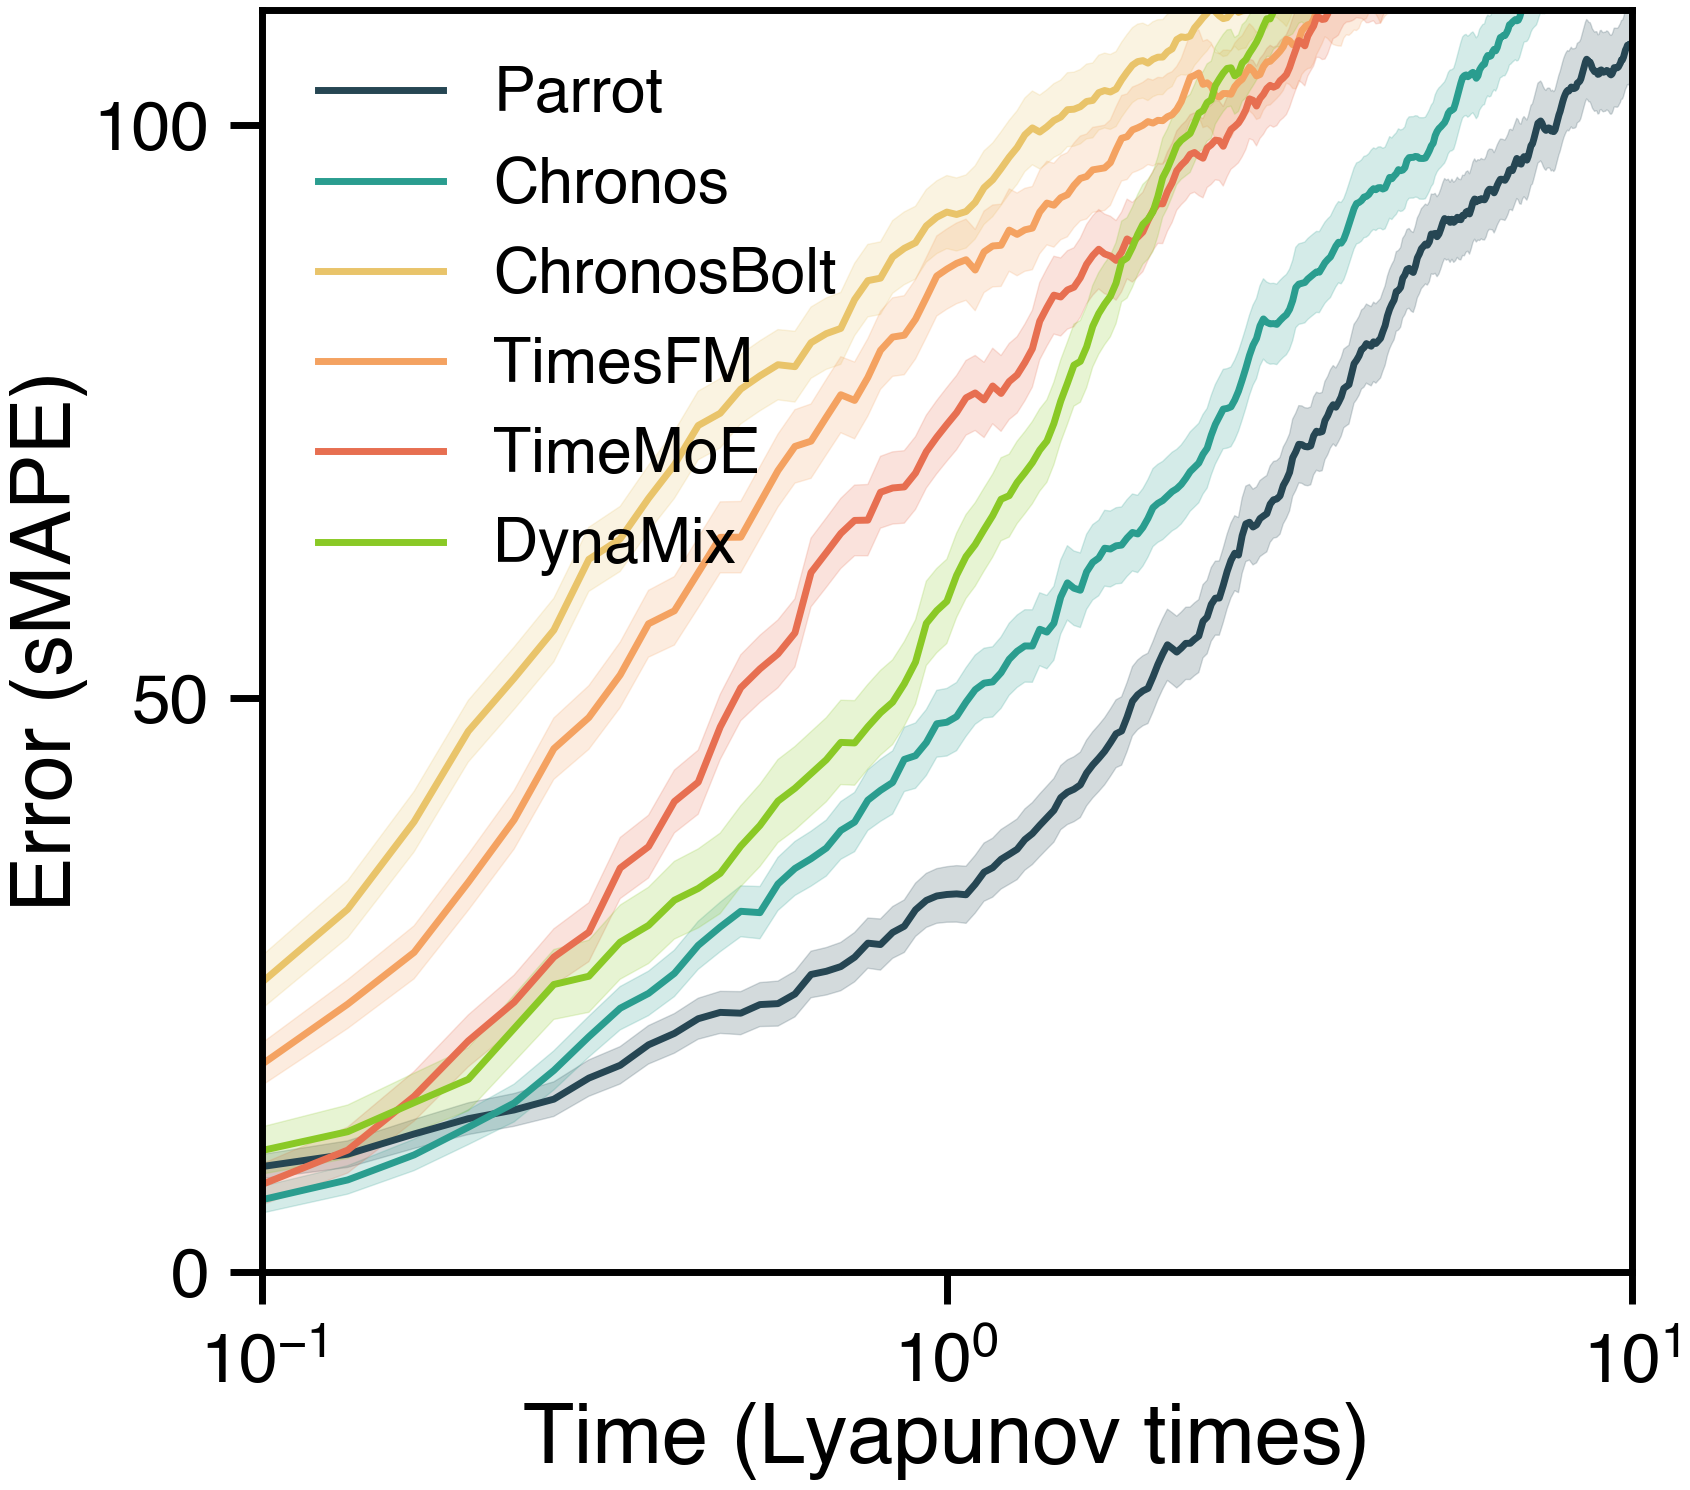

In [13]:
colors = ["#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51", "#8ac926", "#1982c4", "#6a4c93"]

time = np.arange(1/granularity, (forecast_length+1)/granularity, 1/granularity)

# Plot Average VPT vs. Context Length for each equation
fig = plt.figure()
ax = fig.add_subplot(111)

for axis in ['bottom','left']:
  ax.spines[axis].set_linewidth(5)
for axis in ['top','right']:
  ax.spines[axis].set_linewidth(5)
  #ax.spines[axis].set_visible(False)

ax.get_xaxis().tick_bottom()
ax.get_yaxis().tick_left()

fig.set_size_inches(17,15)
plt.xticks(fontsize = 50)
plt.yticks(fontsize = 50)
plt.xlabel(r'Time (Lyapunov times)', fontname="Helvetica", fontsize = 60)
plt.ylabel(r'Error (sMAPE)', fontname="Helvetica", fontsize = 60)
  
context_length = 512

smape_trjs = [Parrot_median_smape[(equation_name, context_length)] for equation_name, ctx in Parrot_median_smape.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[0], label='Parrot')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[0])

smape_trjs = [median_smape[(equation_name, context_length)] for equation_name, ctx in median_smape.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[1], label='Chronos')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[1])

smape_trjs = [ChronosBolt_median_smape[(equation_name, context_length)] for equation_name, ctx in ChronosBolt_median_smape.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[2], label='ChronosBolt')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[2])

smape_trjs = [TimesFM_median_smape[(equation_name, context_length)] for equation_name, ctx in TimesFM_median_smape.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[3], label='TimesFM')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[3])

smape_trjs = [TimeMoE_median_smape[(equation_name, context_length)] for equation_name, ctx in TimeMoE_median_smape.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[4], label='TimeMoE')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[4])

smape_trjs = [dynamix_median_smape[(equation_name, context_length)] for equation_name, ctx in dynamix_median_smape.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[5], label='DynaMix')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[5])

plt.xscale('log')
#plt.yscale('log')

plt.xlim([.1, 10])
plt.ylim([0, 110])

plt.yticks([0, 50, 100])

plt.legend(loc='upper left', frameon=False, prop={'size':45, 'family': 'Helvetica'}, ncol=1)

plt.gca().tick_params(axis='y', pad=15, size=23, width=5)
plt.gca().tick_params(axis='x', pad=20, size=23, width=5)

fig.set_tight_layout(True)
plt.savefig(f'smape_rolling_compare.pdf', bbox_inches='tight')

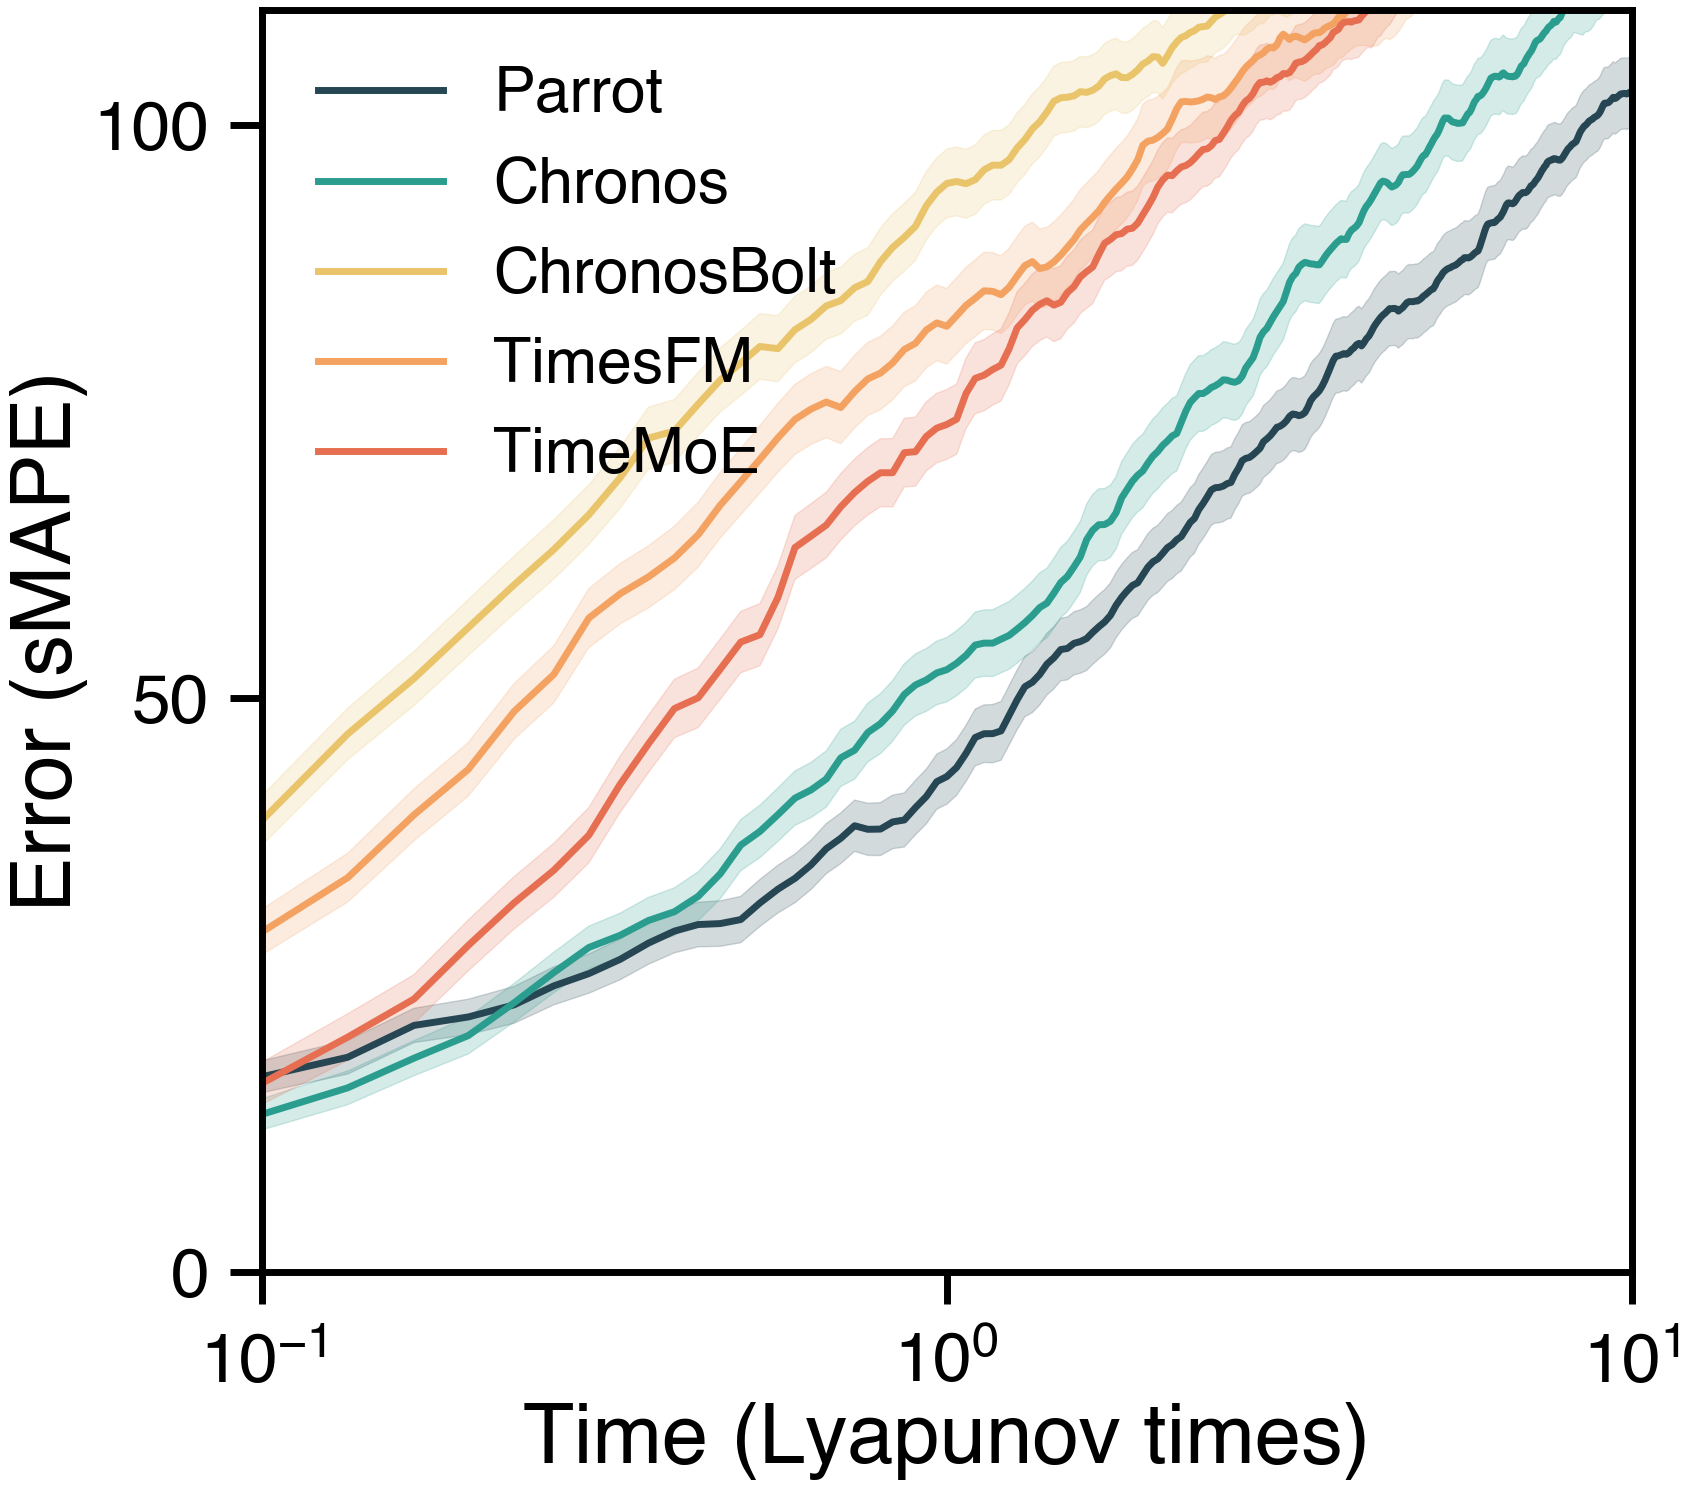

In [106]:
colors = ["#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51"]

time = np.arange(1/granularity, (forecast_length+1)/granularity, 1/granularity)

# Plot Average VPT vs. Context Length for each equation
fig = plt.figure()
ax = fig.add_subplot(111)

for axis in ['bottom','left']:
  ax.spines[axis].set_linewidth(5)
for axis in ['top','right']:
  ax.spines[axis].set_linewidth(5)
  #ax.spines[axis].set_visible(False)

ax.get_xaxis().tick_bottom()
ax.get_yaxis().tick_left()

fig.set_size_inches(17,15)
plt.xticks(fontsize = 50)
plt.yticks(fontsize = 50)
plt.xlabel(r'Time (Lyapunov times)', fontname="Helvetica", fontsize = 60)
plt.ylabel(r'Error (sMAPE)', fontname="Helvetica", fontsize = 60)
  
context_length = 512

smape_trjs = [Parrot_median_smape_2[(equation_name, context_length)] for equation_name, ctx in Parrot_median_smape_2.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[0], label='Parrot')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[0])

smape_trjs = [median_smape_2[(equation_name, context_length)] for equation_name, ctx in median_smape_2.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[1], label='Chronos')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[1])

smape_trjs = [ChronosBolt_median_smape_2[(equation_name, context_length)] for equation_name, ctx in ChronosBolt_median_smape_2.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[2], label='ChronosBolt')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[2])

smape_trjs = [TimesFM_median_smape_2[(equation_name, context_length)] for equation_name, ctx in TimesFM_median_smape_2.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[3], label='TimesFM')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[3])

smape_trjs = [TimeMoE_median_smape_2[(equation_name, context_length)] for equation_name, ctx in TimeMoE_median_smape_2.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[4], label='TimeMoE')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[4])

plt.xscale('log')
#plt.yscale('log')

plt.xlim([.1, 10])
plt.ylim([0, 110])

plt.yticks([0, 50, 100])

plt.legend(loc='upper left', frameon=False, prop={'size':45, 'family': 'Helvetica'}, ncol=1)

plt.gca().tick_params(axis='y', pad=15, size=23, width=5)
plt.gca().tick_params(axis='x', pad=20, size=23, width=5)

fig.set_tight_layout(True)
#plt.savefig(f'smape_rolling_compare_2.pdf', bbox_inches='tight')

In [107]:
def vpt_by_context(data, context_lengths, method, equation_names):
    # Calculate the average VPT across all equations for each context length
    vpt_by_context_ave = []
    vpt_by_context_std = []
    for context_length in context_lengths:
        vpt_values = [data[(equation_name, context_length)] for equation_name, ctx in data.keys() if ctx == context_length]
        if method == 'median':
            vpt_by_context_ave.append(np.median(vpt_values))
        if method =='mean':
            vpt_by_context_ave.append(np.mean(vpt_values))
        vpt_by_context_std.append(np.std(vpt_values)/np.sqrt(len(equation_names)))

    return vpt_by_context_ave, vpt_by_context_std

131


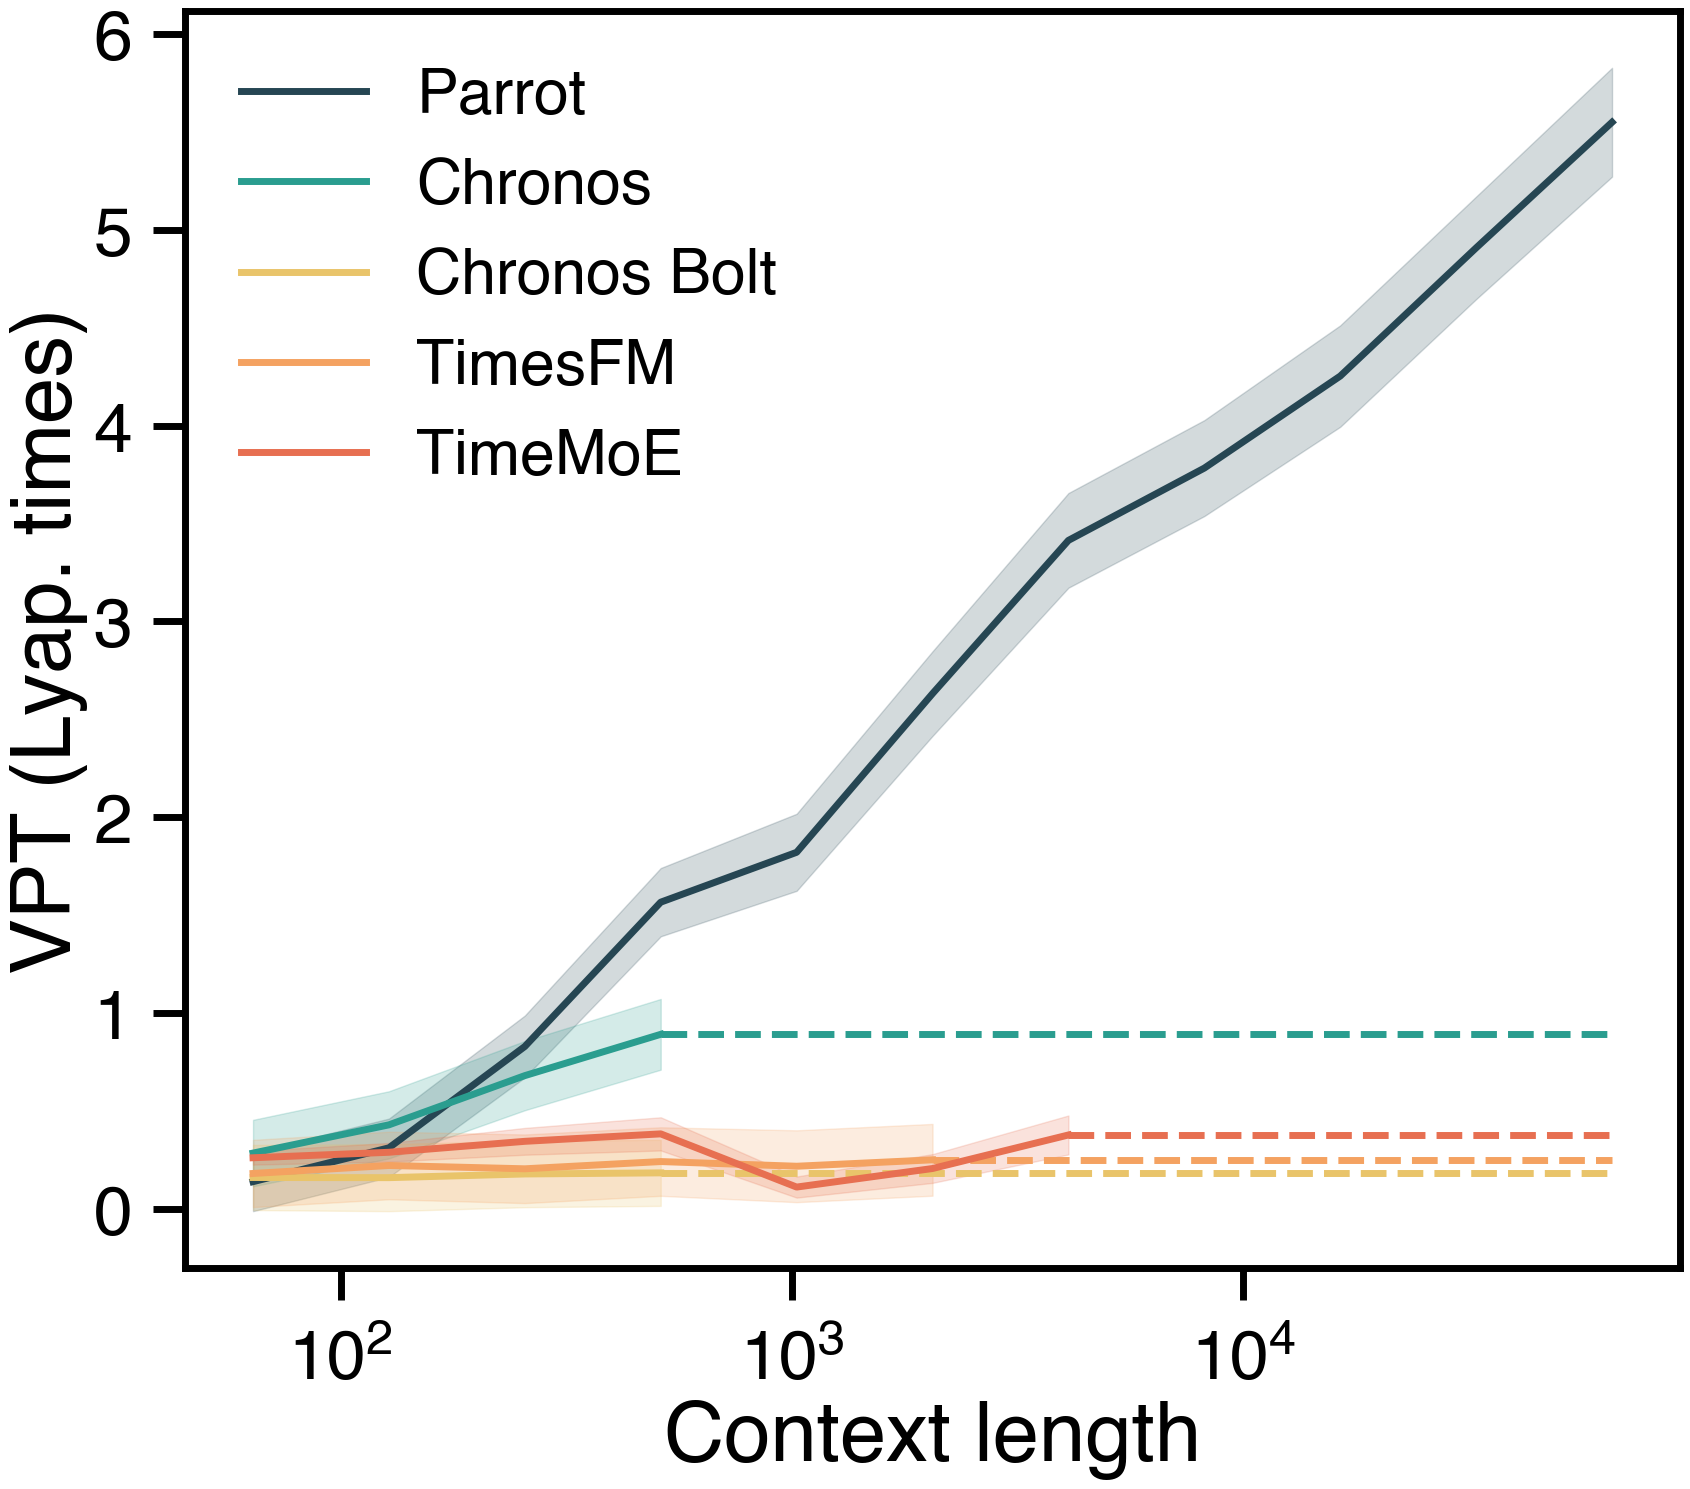

In [108]:
# Extract unique equation names and context lengths
included_equations = equation_names
print(len(included_equations))

vpt_by_context_ave, vpt_by_context_std = vpt_by_context(average_vpt, context_lengths_chronos, method='median', equation_names=included_equations)
ChronosBolt_vpt_by_context_ave, ChronosBolt_vpt_by_context_std = vpt_by_context(ChronosBolt_average_vpt, context_lengths_chronos, method='median', equation_names=included_equations)
Parrot_vpt_by_context_ave, Parrot_vpt_by_context_std = vpt_by_context(Parrot_average_vpt, context_lengths_parrot, method='median', equation_names=included_equations)
TimesFM_vpt_by_context_ave, TimesFM_vpt_by_context_std = vpt_by_context(TimesFM_average_vpt, context_lengths_TimesFM, method='median', equation_names=included_equations)
TimeMoE_vpt_by_context_ave, TimeMoE_vpt_by_context_std = vpt_by_context(TimeMoE_average_vpt, context_lengths_TimeMoE, method='median', equation_names=included_equations)

# Plot Average VPT vs. Context Length for each equation
fig = plt.figure()
ax = fig.add_subplot(111)

for axis in ['bottom','left']:
  ax.spines[axis].set_linewidth(5)
for axis in ['top','right']:
  ax.spines[axis].set_linewidth(5)
  #ax.spines[axis].set_visible(False)

ax.get_xaxis().tick_bottom()
ax.get_yaxis().tick_left()

fig.set_size_inches(17,15)
plt.xticks(fontsize = 50)
plt.yticks(fontsize = 50)
plt.xlabel(r'Context length', fontname="Helvetica", fontsize = 60)
plt.ylabel(r'VPT (Lyap. times)', fontname="Helvetica", fontsize = 60)

plt.plot(context_lengths_parrot, Parrot_vpt_by_context_ave, lw=5, ls='-', alpha=1, color=colors[0], label='Parrot')
ax.fill_between(context_lengths_parrot, np.array(Parrot_vpt_by_context_ave) - np.array(Parrot_vpt_by_context_std), np.array(Parrot_vpt_by_context_ave) + np.array(Parrot_vpt_by_context_std), alpha=0.2, color=colors[0])

plt.plot(context_lengths_chronos[:-1], vpt_by_context_ave[:-1], lw=5, ls='-', alpha=1, color=colors[1], label='Chronos')
plt.plot(2**np.arange(9, 17), vpt_by_context_ave[-2]*np.ones(8), lw=5, ls='--', alpha=1, color=colors[1])
ax.fill_between(context_lengths_chronos[:-1], np.array(vpt_by_context_ave[:-1]) - np.array(vpt_by_context_std[:-1]), np.array(vpt_by_context_ave[:-1]) + np.array(vpt_by_context_std[:-1]), alpha=0.2, color=colors[1])
#plt.plot(context_lengths_chronos, vpt_by_context_med, lw=3, ls='-', alpha=1, color=colors[1], label='Chronos')

plt.plot(context_lengths_chronos[:-1], ChronosBolt_vpt_by_context_ave[:-1], lw=5, ls='-', alpha=1, color=colors[2], label='Chronos Bolt')
plt.plot(2**np.arange(9, 17), ChronosBolt_vpt_by_context_ave[-2]*np.ones(8), lw=5, ls='--', alpha=1, color=colors[2])
ax.fill_between(context_lengths_chronos[:-1], np.array(ChronosBolt_vpt_by_context_ave[:-1]) - np.array(ChronosBolt_vpt_by_context_std[:-1]), np.array(ChronosBolt_vpt_by_context_ave[:-1]) + np.array(ChronosBolt_vpt_by_context_std[:-1]), alpha=0.2, color=colors[2])

plt.plot(context_lengths_TimesFM[:-1], TimesFM_vpt_by_context_ave[:-1], lw=5, ls='-', alpha=1, color=colors[3], label='TimesFM')
plt.plot(2**np.arange(11, 17), TimesFM_vpt_by_context_ave[-2]*np.ones(6), lw=5, ls='--', alpha=1, color=colors[3])
ax.fill_between(context_lengths_TimesFM[:-1], np.array(TimesFM_vpt_by_context_ave[:-1]) - np.array(TimesFM_vpt_by_context_std[:-1]), np.array(TimesFM_vpt_by_context_ave[:-1]) + np.array(TimesFM_vpt_by_context_std[:-1]), alpha=0.2, color=colors[3])

plt.plot(context_lengths_TimeMoE[:-1], TimeMoE_vpt_by_context_ave[:-1], lw=5, ls='-', alpha=1, color=colors[4], label='TimeMoE')
plt.plot(2**np.arange(12, 17), TimeMoE_vpt_by_context_ave[-2]*np.ones(5), lw=5, ls='--', alpha=1, color=colors[4])
ax.fill_between(context_lengths_TimeMoE[:-1], np.array(TimeMoE_vpt_by_context_ave[:-1]) - np.array(TimeMoE_vpt_by_context_std[:-1]), np.array(TimeMoE_vpt_by_context_ave[:-1]) + np.array(TimeMoE_vpt_by_context_std[:-1]), alpha=0.2, color=colors[4])

plt.xscale('log')
#plt.yscale('log')

plt.legend(loc='upper left', frameon=False, prop={'size':45}, ncol=1)

plt.gca().tick_params(axis='y', pad=15, size=23, width=5)
plt.gca().tick_params(axis='x', pad=20, size=23, width=5)

fig.set_tight_layout(True)
plt.savefig(f'vpt_vs_context_length_compare_normalized.pdf', bbox_inches='tight')

131


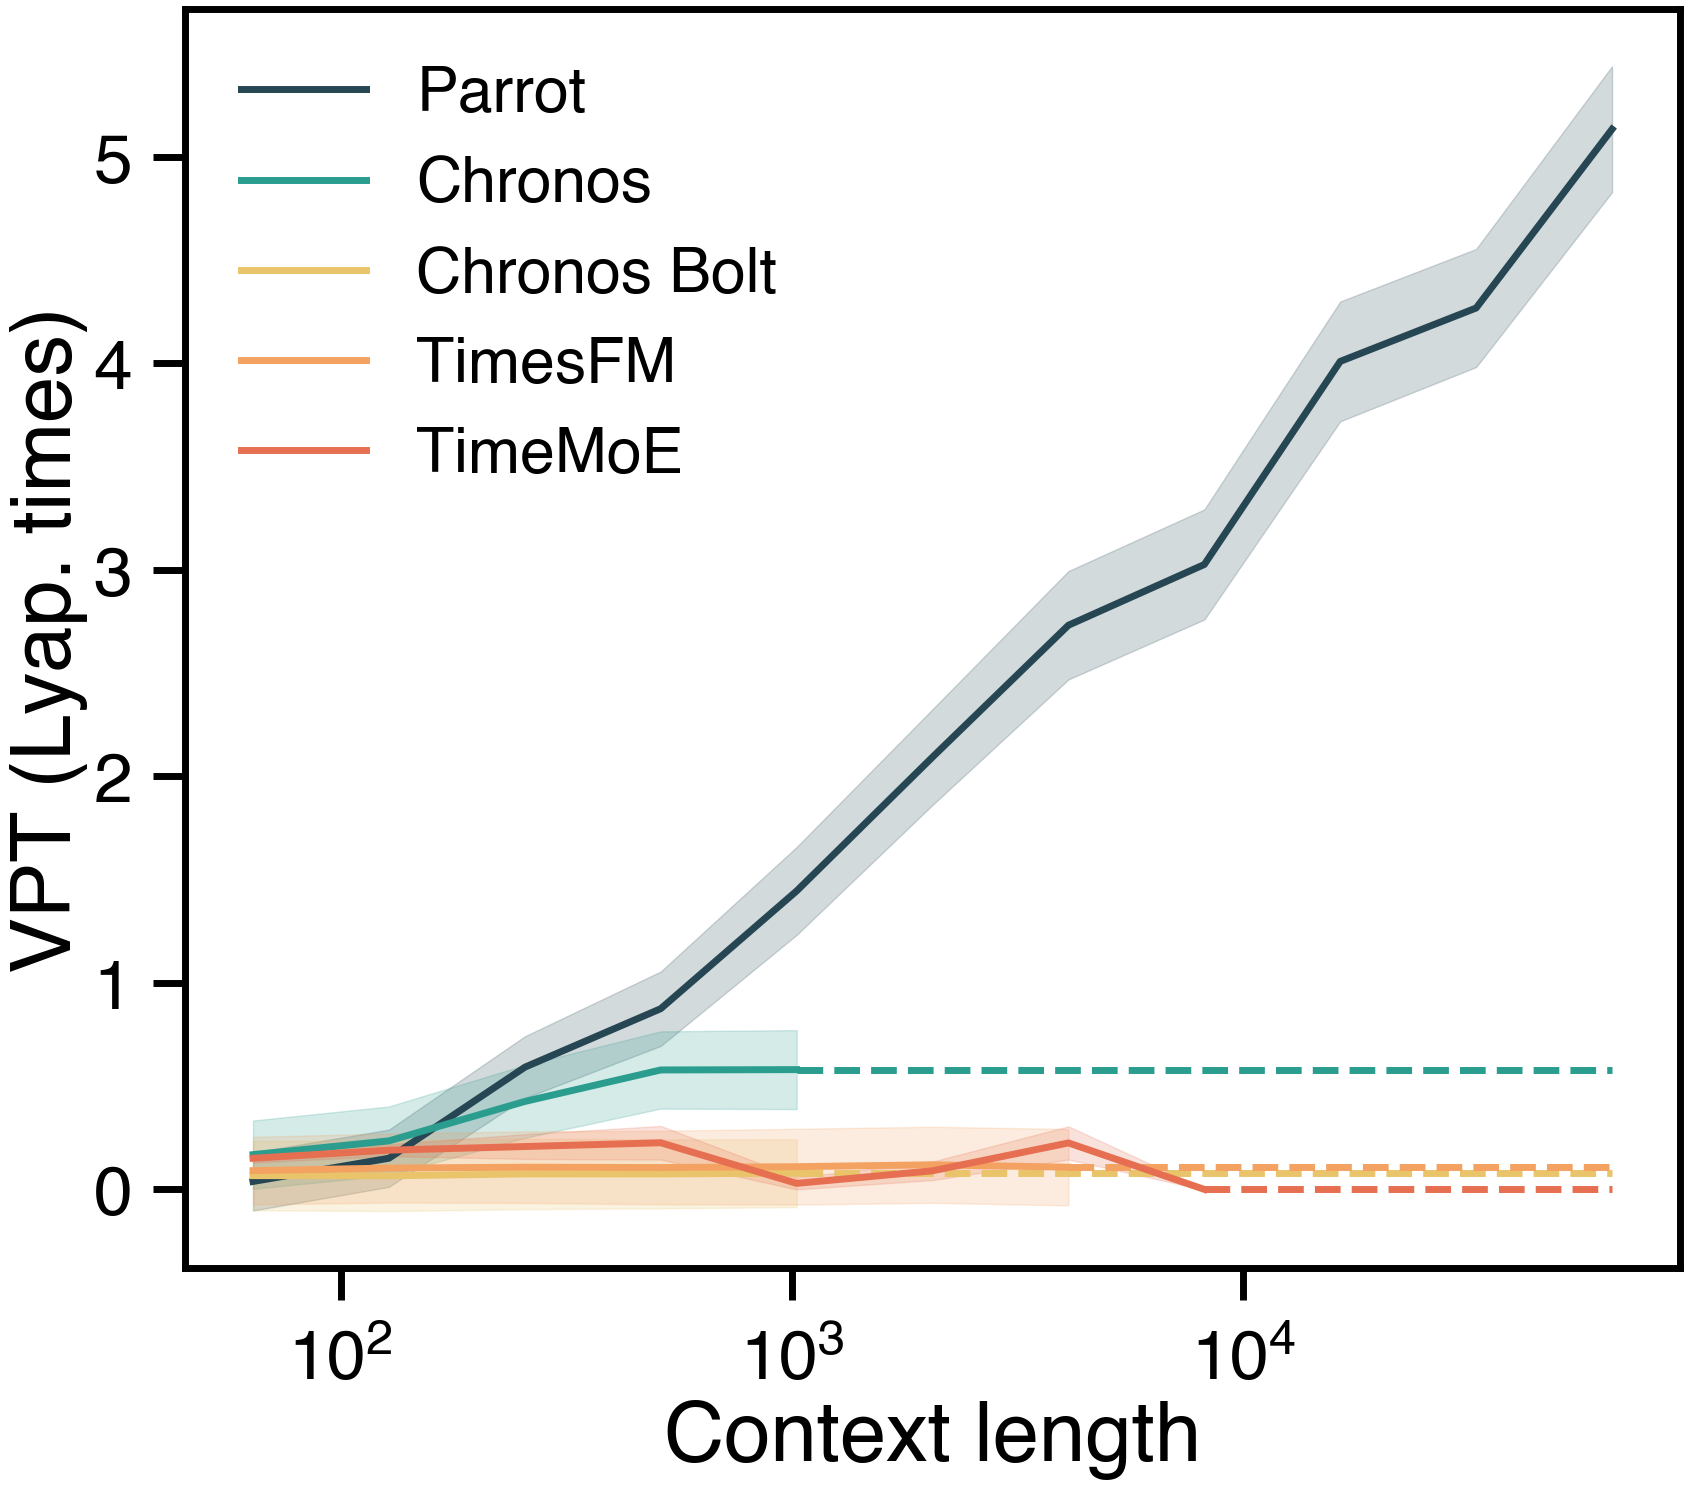

In [109]:
# Extract unique equation names and context lengths
included_equations = equation_names
print(len(included_equations))

vpt_by_context_ave, vpt_by_context_std = vpt_by_context(average_vpt_2, context_lengths_chronos, method='median', equation_names=included_equations)
ChronosBolt_vpt_by_context_ave, ChronosBolt_vpt_by_context_std = vpt_by_context(ChronosBolt_average_vpt_2, context_lengths_chronos, method='median', equation_names=included_equations)
Parrot_vpt_by_context_ave, Parrot_vpt_by_context_std = vpt_by_context(Parrot_average_vpt_2, context_lengths_parrot, method='median', equation_names=included_equations)
TimesFM_vpt_by_context_ave, TimesFM_vpt_by_context_std = vpt_by_context(TimesFM_average_vpt_2, context_lengths_TimesFM, method='median', equation_names=included_equations)
TimeMoE_vpt_by_context_ave, TimeMoE_vpt_by_context_std = vpt_by_context(TimeMoE_average_vpt_2, context_lengths_TimeMoE, method='median', equation_names=included_equations)

# Plot Average VPT vs. Context Length for each equation
fig = plt.figure()
ax = fig.add_subplot(111)

for axis in ['bottom','left']:
  ax.spines[axis].set_linewidth(5)
for axis in ['top','right']:
  ax.spines[axis].set_linewidth(5)
  #ax.spines[axis].set_visible(False)

ax.get_xaxis().tick_bottom()
ax.get_yaxis().tick_left()

fig.set_size_inches(17,15)
plt.xticks(fontsize = 50)
plt.yticks(fontsize = 50)
plt.xlabel(r'Context length', fontname="Helvetica", fontsize = 60)
plt.ylabel(r'VPT (Lyap. times)', fontname="Helvetica", fontsize = 60)

plt.plot(context_lengths_parrot, Parrot_vpt_by_context_ave, lw=5, ls='-', alpha=1, color=colors[0], label='Parrot')
ax.fill_between(context_lengths_parrot, np.array(Parrot_vpt_by_context_ave) - np.array(Parrot_vpt_by_context_std), np.array(Parrot_vpt_by_context_ave) + np.array(Parrot_vpt_by_context_std), alpha=0.2, color=colors[0])

plt.plot(context_lengths_chronos, vpt_by_context_ave, lw=5, ls='-', alpha=1, color=colors[1], label='Chronos')
plt.plot(2**np.arange(10, 17), vpt_by_context_ave[-1]*np.ones(7), lw=5, ls='--', alpha=1, color=colors[1])
ax.fill_between(context_lengths_chronos, np.array(vpt_by_context_ave) - np.array(vpt_by_context_std), np.array(vpt_by_context_ave) + np.array(vpt_by_context_std), alpha=0.2, color=colors[1])
#plt.plot(context_lengths_chronos, vpt_by_context_med, lw=3, ls='-', alpha=1, color=colors[1], label='Chronos')

plt.plot(context_lengths_chronos, ChronosBolt_vpt_by_context_ave, lw=5, ls='-', alpha=1, color=colors[2], label='Chronos Bolt')
plt.plot(2**np.arange(10, 17), ChronosBolt_vpt_by_context_ave[-1]*np.ones(7), lw=5, ls='--', alpha=1, color=colors[2])
ax.fill_between(context_lengths_chronos, np.array(ChronosBolt_vpt_by_context_ave) - np.array(ChronosBolt_vpt_by_context_std), np.array(ChronosBolt_vpt_by_context_ave) + np.array(ChronosBolt_vpt_by_context_std), alpha=0.2, color=colors[2])

plt.plot(context_lengths_TimesFM, TimesFM_vpt_by_context_ave, lw=5, ls='-', alpha=1, color=colors[3], label='TimesFM')
plt.plot(2**np.arange(12, 17), TimesFM_vpt_by_context_ave[-1]*np.ones(5), lw=5, ls='--', alpha=1, color=colors[3])
ax.fill_between(context_lengths_TimesFM, np.array(TimesFM_vpt_by_context_ave) - np.array(TimesFM_vpt_by_context_std), np.array(TimesFM_vpt_by_context_ave) + np.array(TimesFM_vpt_by_context_std), alpha=0.2, color=colors[3])

plt.plot(context_lengths_TimeMoE, TimeMoE_vpt_by_context_ave, lw=5, ls='-', alpha=1, color=colors[4], label='TimeMoE')
plt.plot(2**np.arange(13, 17), TimeMoE_vpt_by_context_ave[-1]*np.ones(4), lw=5, ls='--', alpha=1, color=colors[4])
ax.fill_between(context_lengths_TimeMoE, np.array(TimeMoE_vpt_by_context_ave) - np.array(TimeMoE_vpt_by_context_std), np.array(TimeMoE_vpt_by_context_ave) + np.array(TimeMoE_vpt_by_context_std), alpha=0.2, color=colors[4])

plt.xscale('log')
#plt.yscale('log')

plt.legend(loc='upper left', frameon=False, prop={'size':45}, ncol=1)

plt.gca().tick_params(axis='y', pad=15, size=23, width=5)
plt.gca().tick_params(axis='x', pad=20, size=23, width=5)

fig.set_tight_layout(True)
#plt.savefig(f'vpt_vs_context_length_compare_2.pdf', bbox_inches='tight')

In [110]:
def qua_by_context(data, context_lengths, method, equation_names):
    # Calculate the average quantity across all equations for each context length
    qua_by_context_ave = []
    qua_by_context_std = []
    for context_length in context_lengths:
        values = [data[(equation_name, context_length)] for equation_name, ctx in data.keys() if ctx == context_length]
        if method == 'median':
            qua_by_context_ave.append(np.median(values))
        if method =='mean':
            qua_by_context_ave.append(np.mean(values))
        qua_by_context_std.append(np.std(values))#/np.sqrt(len(equation_names)))

    return qua_by_context_ave, qua_by_context_std

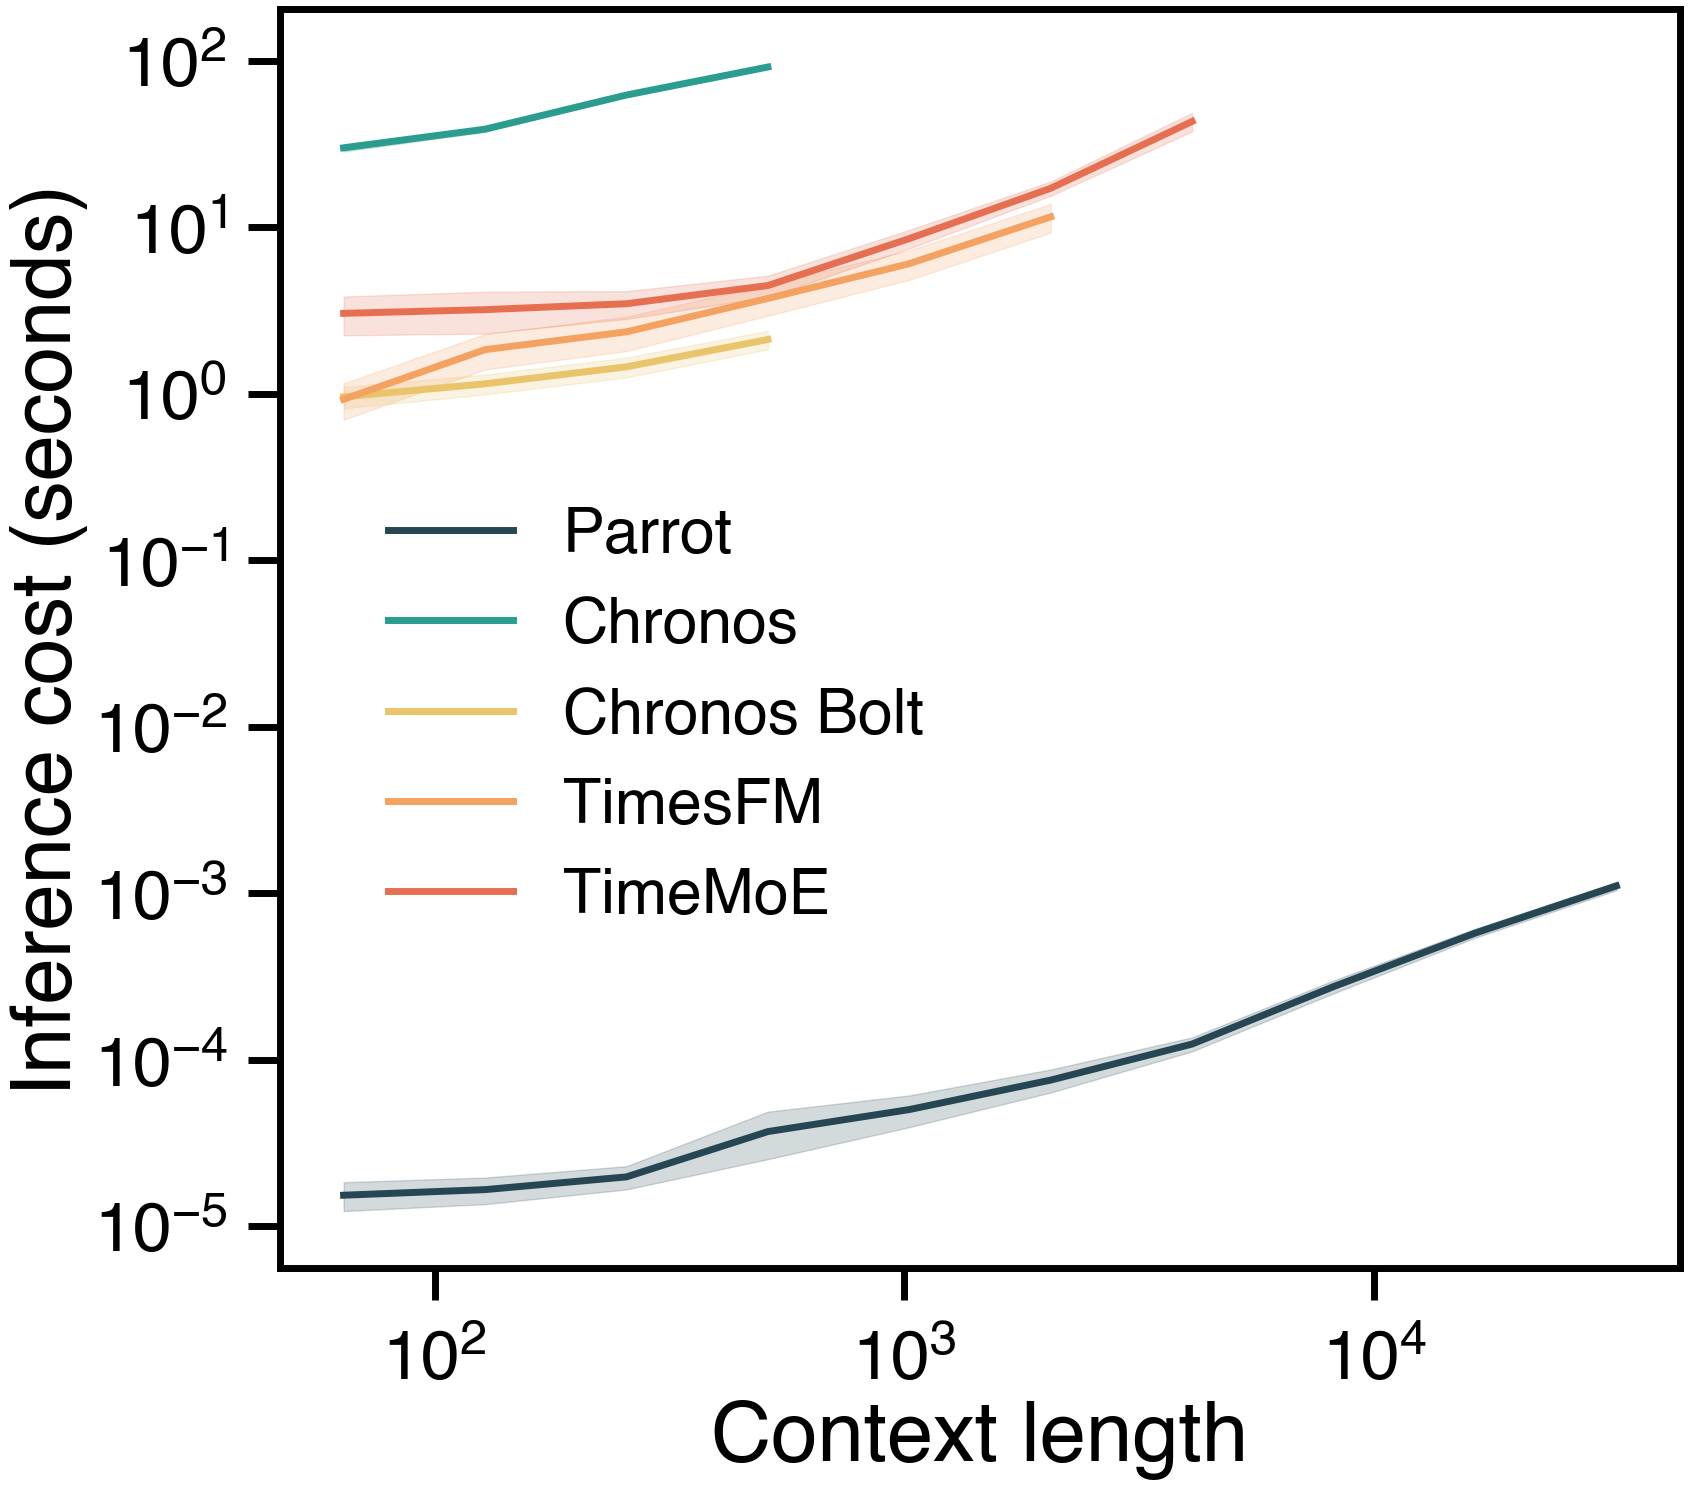

In [111]:
cost_by_context_ave, cost_by_context_std = qua_by_context(average_cpu_cost, context_lengths_chronos[:-1], method='median', equation_names=included_equations)
ChronosBolt_cost_by_context_ave, ChronosBolt_cost_by_context_std = qua_by_context(ChronosBolt_average_cpu_cost, context_lengths_chronos[:-1], method='median', equation_names=included_equations)
Parrot_cost_by_context_ave, Parrot_cost_by_context_std = qua_by_context(Parrot_average_cpu_cost, context_lengths_parrot[:-1], method='median', equation_names=included_equations)
TimesFM_cost_by_context_ave, TimesFM_cost_by_context_std = qua_by_context(TimesFM_average_cpu_cost, context_lengths_TimesFM[:-1], method='median', equation_names=included_equations)
TimeMoE_cost_by_context_ave, TimeMoE_cost_by_context_std = qua_by_context(TimeMoE_average_cpu_cost, context_lengths_TimeMoE[:-1], method='median', equation_names=included_equations)

fig = plt.figure()
ax = fig.add_subplot(111)

for axis in ['bottom','left']:
  ax.spines[axis].set_linewidth(5)
for axis in ['top','right']:
  ax.spines[axis].set_linewidth(5)
  #ax.spines[axis].set_visible(False)

ax.get_xaxis().tick_bottom()
ax.get_yaxis().tick_left()

fig.set_size_inches(17,15)
plt.xticks(fontsize = 50)
plt.yticks(fontsize = 50)
plt.xlabel(r'Context length', fontname="Helvetica", fontsize = 60)
plt.ylabel(r'Inference cost (seconds)', fontname="Helvetica", fontsize = 60)

plt.plot(context_lengths_parrot[:-1], Parrot_cost_by_context_ave, lw=5, ls='-', alpha=1, color=colors[0], label='Parrot')
ax.fill_between(context_lengths_parrot[:-1], np.array(Parrot_cost_by_context_ave) - np.array(Parrot_cost_by_context_std), np.array(Parrot_cost_by_context_ave) + np.array(Parrot_cost_by_context_std), alpha=0.2, color=colors[0])

plt.plot(context_lengths_chronos[:-1], cost_by_context_ave, lw=5, ls='-', alpha=1, color=colors[1], label='Chronos')
ax.fill_between(context_lengths_chronos[:-1], np.array(cost_by_context_ave) - np.array(cost_by_context_std), np.array(cost_by_context_ave) + np.array(cost_by_context_std), alpha=0.2, color=colors[1])

plt.plot(context_lengths_chronos[:-1], ChronosBolt_cost_by_context_ave, lw=5, ls='-', alpha=1, color=colors[2], label='Chronos Bolt')
ax.fill_between(context_lengths_chronos[:-1], np.array(ChronosBolt_cost_by_context_ave) - np.array(ChronosBolt_cost_by_context_std), np.array(ChronosBolt_cost_by_context_ave) + np.array(ChronosBolt_cost_by_context_std), alpha=0.2, color=colors[2])

plt.plot(context_lengths_TimesFM[:-1], TimesFM_cost_by_context_ave, lw=5, ls='-', alpha=1, color=colors[3], label='TimesFM')
ax.fill_between(context_lengths_TimesFM[:-1], np.array(TimesFM_cost_by_context_ave) - np.array(TimesFM_cost_by_context_std), np.array(TimesFM_cost_by_context_ave) + np.array(TimesFM_cost_by_context_std), alpha=0.2, color=colors[3])

plt.plot(context_lengths_TimeMoE[:-1], TimeMoE_cost_by_context_ave, lw=5, ls='-', alpha=1, color=colors[4], label='TimeMoE')
ax.fill_between(context_lengths_TimeMoE[:-1], np.array(TimeMoE_cost_by_context_ave) - np.array(TimeMoE_cost_by_context_std), np.array(TimeMoE_cost_by_context_ave) + np.array(TimeMoE_cost_by_context_std), alpha=0.2, color=colors[4])

plt.xscale('log')
plt.yscale('log')

plt.legend(loc='upper right', bbox_to_anchor=(.5, 0.65), frameon=False, prop={'size':45}, ncol=1)

plt.gca().tick_params(axis='y', pad=15, size=23, width=5)
plt.gca().tick_params(axis='x', pad=20, size=23, width=5)

fig.set_tight_layout(True)
#plt.savefig(f'cost_vs_context_length.pdf', bbox_inches='tight')

In [112]:
from scipy.stats import spearmanr

def cdim_spearmanr(average_data, median_data, context_lengths):
    # Calculate the average correlation dimension (cdim) across all equations for each context length
    correlation_by_context_ave = []
    correlation_by_context_med = []

    for context_length in context_lengths:
        try:
            # Collect predicted and true values for the average correlation dimension
            all_cdim_pred_ave = []
            all_cdim_true_ave = []
            all_cdim_pred_med = []
            all_cdim_true_med = []

            for (equation_name, ctx), pred_val in average_data.items():
                if ctx == context_length:
                    all_cdim_pred_ave.append(pred_val[0])
                    all_cdim_true_ave.append(pred_val[1])

            for (equation_name, ctx), pred_val in median_data.items():
                if ctx == context_length:
                    all_cdim_pred_med.append(pred_val[0])
                    all_cdim_true_med.append(pred_val[1])

            # Compute Spearman correlation for average values
            if all_cdim_pred_ave and all_cdim_true_ave:
                scorr_val_ave = spearmanr(all_cdim_pred_ave, all_cdim_true_ave).statistic
                correlation_by_context_ave.append(scorr_val_ave)
            else:
                correlation_by_context_ave.append(None)

            # Compute Spearman correlation for median values
            if all_cdim_pred_med and all_cdim_true_med:
                scorr_val_med = spearmanr(all_cdim_pred_med, all_cdim_true_med).statistic
                correlation_by_context_med.append(scorr_val_med)
            else:
                correlation_by_context_med.append(None)

        except Exception as e:
            print(f"Error processing context length {context_length}: {e}")
            correlation_by_context_ave.append(None)
            correlation_by_context_med.append(None)

    return correlation_by_context_ave, correlation_by_context_med

Number of included equations: 131


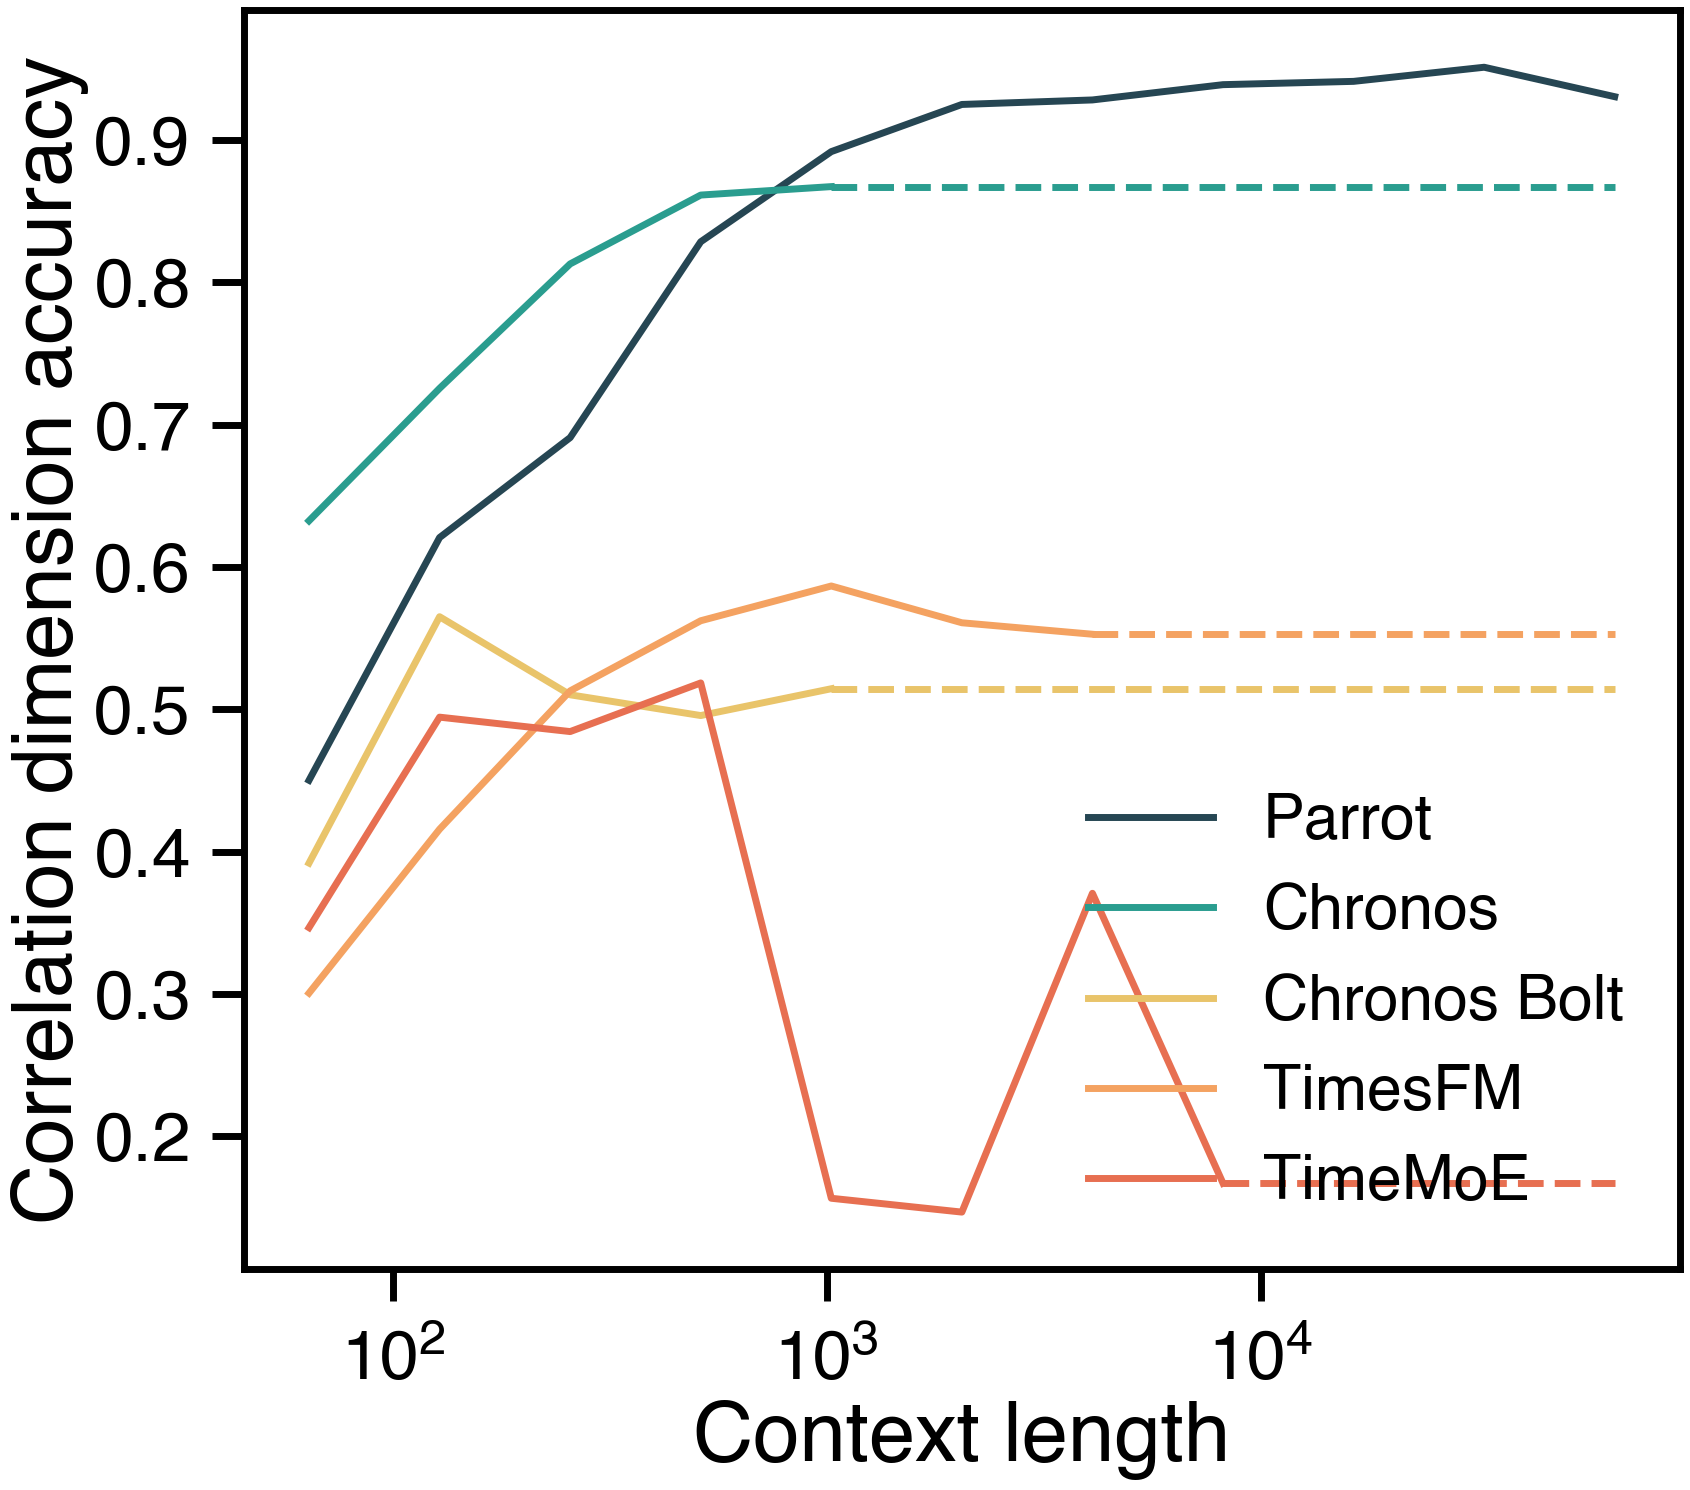

In [113]:
# Extract unique equation names and context lengths
included_equations = equation_names
print(f"Number of included equations: {len(included_equations)}")

correlation_by_context_ave, correlation_by_context_med = cdim_spearmanr(average_cdim, median_cdim, context_lengths_chronos)
ChronosBolt_correlation_by_context_ave, ChronosBolt_correlation_by_context_med = cdim_spearmanr(ChronosBolt_average_cdim, ChronosBolt_median_cdim, context_lengths_chronos)
Parrot_correlation_by_context_ave, Parrot_correlation_by_context_med = cdim_spearmanr(Parrot_average_cdim, Parrot_median_cdim, context_lengths_parrot)
TimesFM_correlation_by_context_ave, TimesFM_correlation_by_context_med = cdim_spearmanr(TimesFM_average_cdim, TimesFM_median_cdim, context_lengths_TimesFM)
TimeMoE_correlation_by_context_ave, TimeMoE_correlation_by_context_med = cdim_spearmanr(TimeMoE_average_cdim, TimeMoE_median_cdim, context_lengths_TimeMoE)

# Plot Average VPT vs. Context Length for each equation
fig = plt.figure()
ax = fig.add_subplot(111)

# Adjust axis styles
for axis in ['bottom','left']:
  ax.spines[axis].set_linewidth(5)
for axis in ['top','right']:
  ax.spines[axis].set_linewidth(5)
  #ax.spines[axis].set_visible(False)

ax.get_xaxis().tick_bottom()
ax.get_yaxis().tick_left()

fig.set_size_inches(17, 15)
plt.xticks(fontsize=50)
plt.yticks(fontsize=50)
plt.xlabel(r'Context length', fontsize=60)
plt.ylabel(r'Correlation dimension accuracy', fontsize=60)

plt.plot(context_lengths_parrot, Parrot_correlation_by_context_med, lw=5, ls='-', alpha=1, color=colors[0], label='Parrot')

plt.plot(context_lengths_chronos, correlation_by_context_med, lw=5, ls='-', alpha=1, color=colors[1], label='Chronos')
plt.plot(2**np.arange(10, 17), correlation_by_context_med[-1]*np.ones(7), lw=5, ls='--', alpha=1, color=colors[1])

plt.plot(context_lengths_chronos, ChronosBolt_correlation_by_context_med, lw=5, ls='-', alpha=1, color=colors[2], label='Chronos Bolt')
plt.plot(2**np.arange(10, 17), ChronosBolt_correlation_by_context_med[-1]*np.ones(7), lw=5, ls='--', alpha=1, color=colors[2])

plt.plot(context_lengths_TimesFM, TimesFM_correlation_by_context_med, lw=5, ls='-', alpha=1, color=colors[3], label='TimesFM')
plt.plot(2**np.arange(12, 17), TimesFM_correlation_by_context_med[-1]*np.ones(5), lw=5, ls='--', alpha=1, color=colors[3])

plt.plot(context_lengths_TimeMoE, TimeMoE_correlation_by_context_med, lw=5, ls='-', alpha=1, color=colors[4], label='TimeMoE')
plt.plot(2**np.arange(13, 17), TimeMoE_correlation_by_context_med[-1]*np.ones(4), lw=5, ls='--', alpha=1, color=colors[4])

plt.xscale('log')
plt.legend(loc='lower right', frameon=False, prop={'size': 45}, ncol=1)

# Adjust tick parameters
plt.gca().tick_params(axis='y', pad=15, size=23, width=5)
plt.gca().tick_params(axis='x', pad=20, size=23, width=5)

fig.tight_layout()
#plt.savefig('cdim_vs_context_length_compare.pdf', bbox_inches='tight')

In [114]:
def kl_by_context(data, context_lengths, method):
    # Calculate the average KL Divergence across all equations for each context length
    kl_by_context_ave = []
    for context_length in context_lengths:
        kl_values = [data[(equation_name, context_length)] for equation_name, ctx in data.keys() if ctx == context_length]
        if method == 'median':
            kl_by_context_ave.append(np.nanmedian(kl_values))
        if method =='mean':
            kl_by_context_ave.append(np.nanmean(kl_values))

    return kl_by_context_ave

131


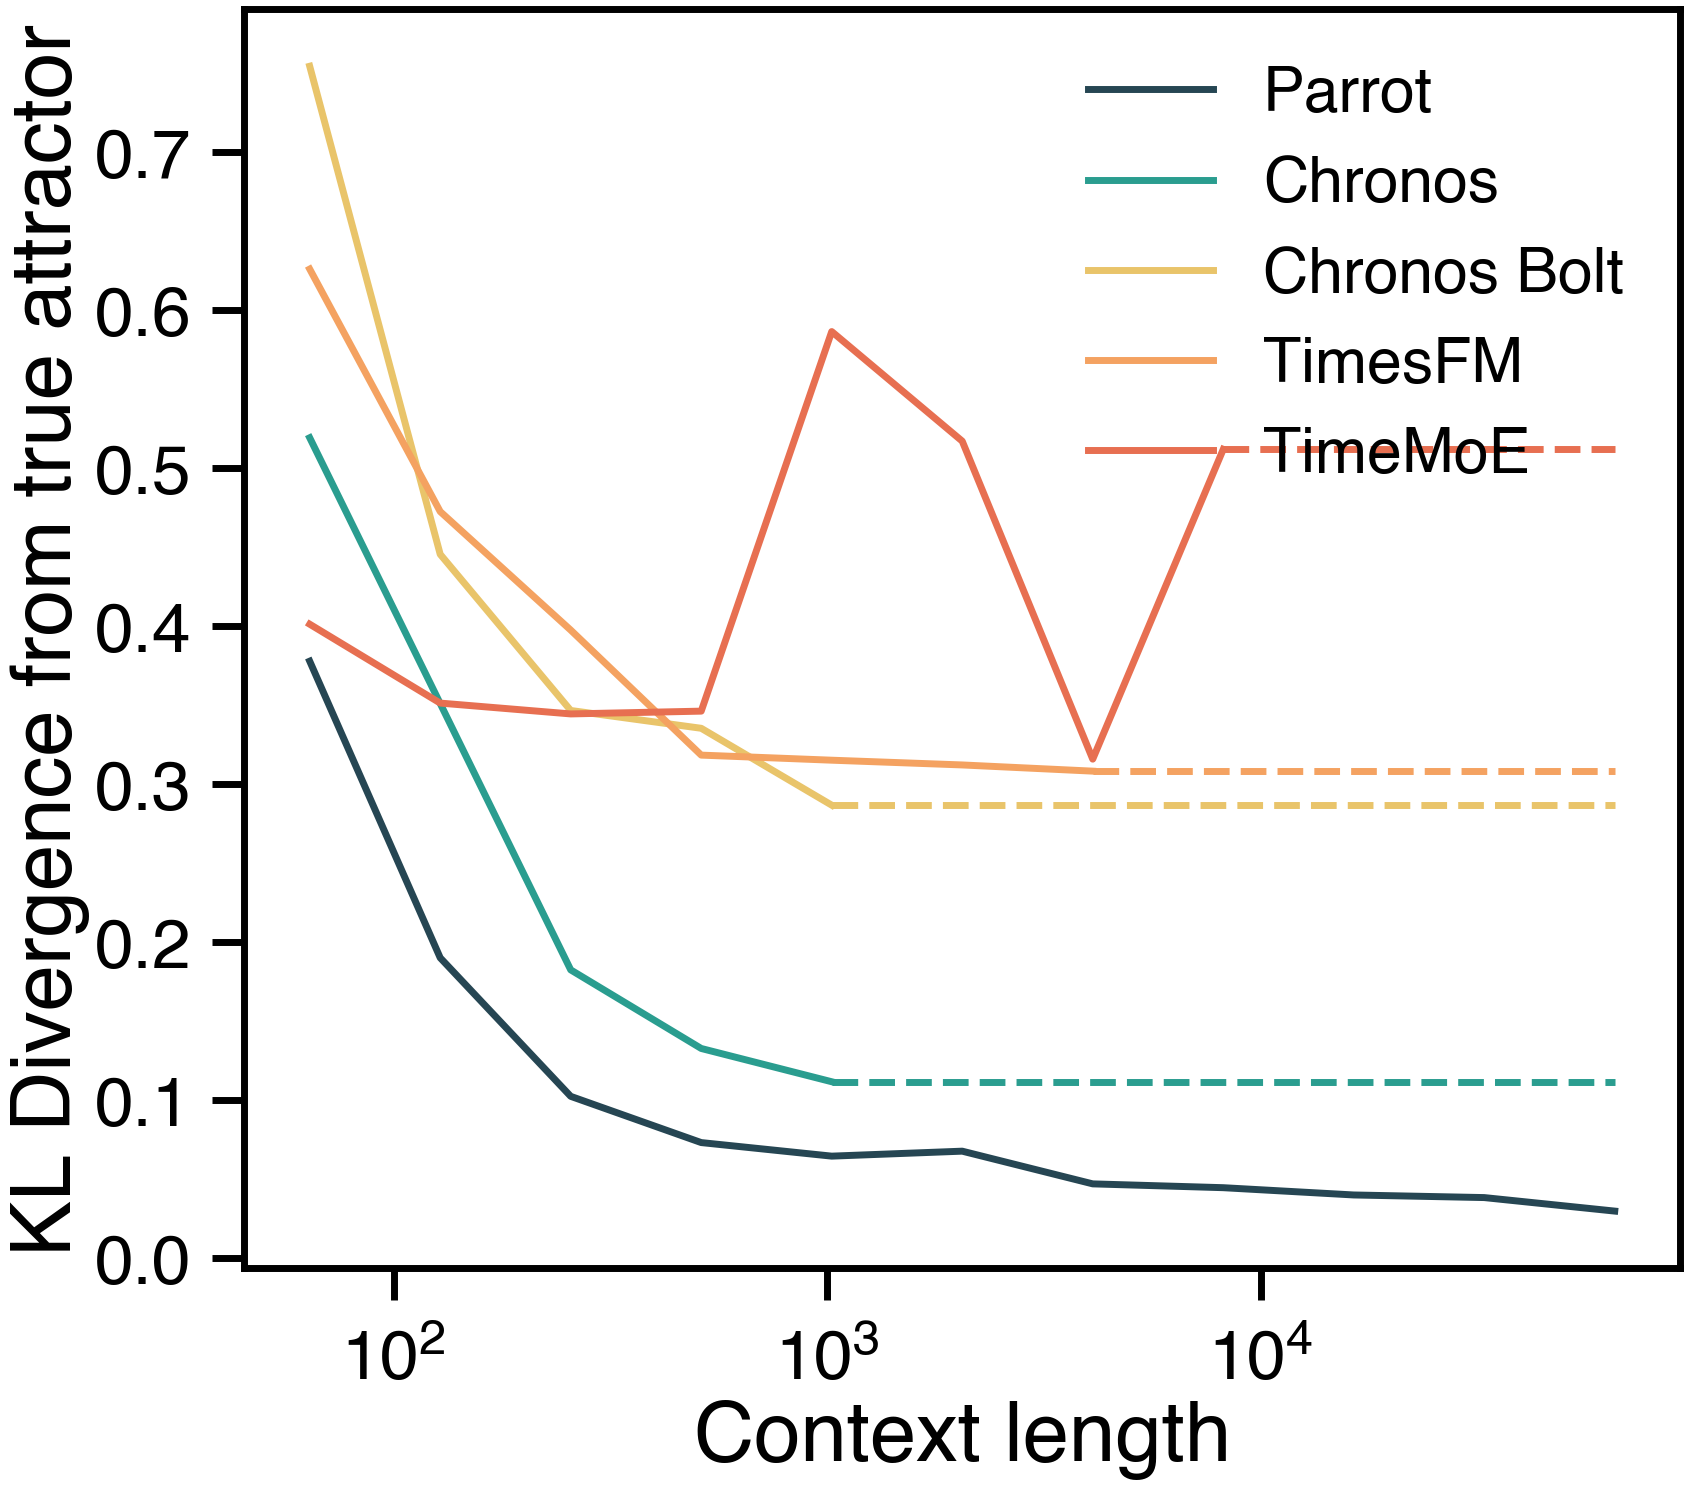

In [115]:
# Extract unique equation names and context lengths
included_equations = equation_names
print(len(included_equations))

kl_by_context_ave = kl_by_context(average_kl, context_lengths_chronos, method='median')
ChronosBolt_kl_by_context_ave = kl_by_context(ChronosBolt_average_kl, context_lengths_chronos, method='median')
Parrot_kl_by_context_ave = kl_by_context(Parrot_average_kl, context_lengths_parrot, method='median')
TimesFM_kl_by_context_ave = kl_by_context(TimesFM_average_kl, context_lengths_TimesFM, method='median')
TimeMoE_kl_by_context_ave = kl_by_context(TimeMoE_average_kl, context_lengths_TimeMoE, method='median')

# Plot Average VPT vs. Context Length for each equation
fig = plt.figure()
ax = fig.add_subplot(111)

for axis in ['bottom','left']:
  ax.spines[axis].set_linewidth(5)
for axis in ['top','right']:
  ax.spines[axis].set_linewidth(5)
  #ax.spines[axis].set_visible(False)

ax.get_xaxis().tick_bottom()
ax.get_yaxis().tick_left()

fig.set_size_inches(17,15)
plt.xticks(fontsize = 50)
plt.yticks(fontsize = 50)
plt.xlabel(r'Context length',fontsize = 60)
plt.ylabel(r'KL Divergence from true attractor',fontsize = 60)

plt.plot(context_lengths_parrot, Parrot_kl_by_context_ave, lw=5, ls='-', alpha=1, color=colors[0], label='Parrot')

plt.plot(context_lengths_chronos, kl_by_context_ave, lw=5, ls='-', alpha=1, color=colors[1], label='Chronos')
plt.plot(2**np.arange(10, 17), kl_by_context_ave[-1]*np.ones(7), lw=5, ls='--', alpha=1, color=colors[1])

plt.plot(context_lengths_chronos, ChronosBolt_kl_by_context_ave, lw=5, ls='-', alpha=1, color=colors[2], label='Chronos Bolt')
plt.plot(2**np.arange(10, 17), ChronosBolt_kl_by_context_ave[-1]*np.ones(7), lw=5, ls='--', alpha=1, color=colors[2])

plt.plot(context_lengths_TimesFM, TimesFM_kl_by_context_ave, lw=5, ls='-', alpha=1, color=colors[3], label='TimesFM')
plt.plot(2**np.arange(12, 17), TimesFM_kl_by_context_ave[-1]*np.ones(5), lw=5, ls='--', alpha=1, color=colors[3])

plt.plot(context_lengths_TimeMoE, TimeMoE_kl_by_context_ave, lw=5, ls='-', alpha=1, color=colors[4], label='TimeMoE')
plt.plot(2**np.arange(13, 17), TimeMoE_kl_by_context_ave[-1]*np.ones(4), lw=5, ls='--', alpha=1, color=colors[4])

plt.xscale('log')
#plt.yscale('log')

plt.legend(loc='upper right', frameon=False, prop={'size':45}, ncol=1)

plt.gca().tick_params(axis='y', pad=15, size=23, width=5)
plt.gca().tick_params(axis='x', pad=20, size=23, width=5)

fig.set_tight_layout(True)
#plt.savefig(f'KL_vs_context_length_compare.pdf', bbox_inches='tight')

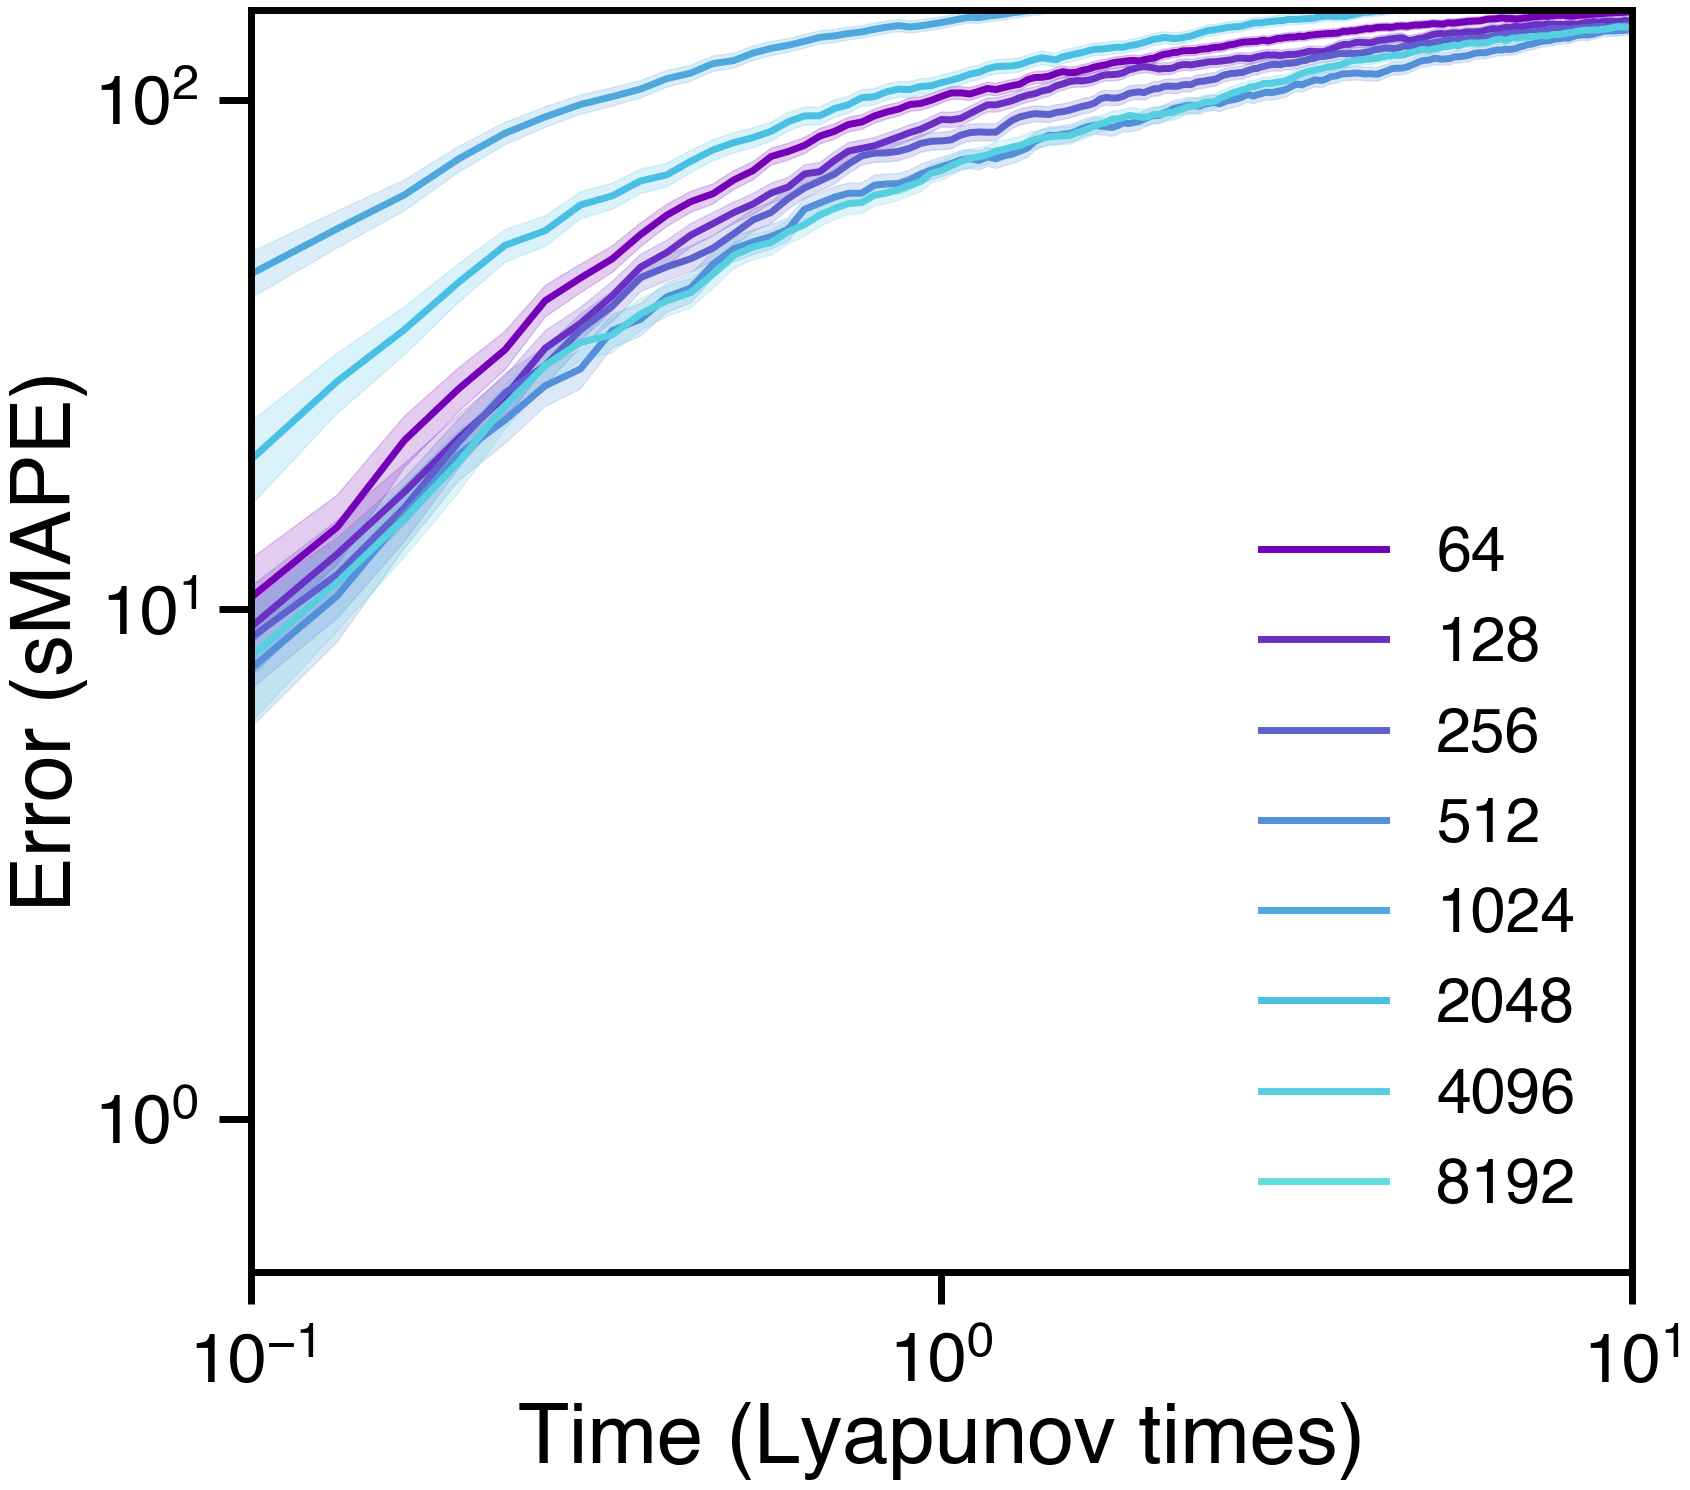

In [118]:
#import degas as dg
colors = ['#f94144', '#f3722c', '#f8961e', '#f9844a', '#f9c74f', '#90be6d', '#43aa8b', '#4d908e', '#577590', '#277da1']
colors = ["#7400b8","#6930c3","#5e60ce","#5390d9","#4ea8de","#48bfe3","#56cfe1","#64dfdf","#72efdd","#80ffdb"]

time = np.arange(1/granularity, (forecast_length+1)/granularity, 1/granularity)

# Plot Average VPT vs. Context Length for each equation
fig = plt.figure()
ax = fig.add_subplot(111)

for axis in ['bottom','left']:
  ax.spines[axis].set_linewidth(5)
for axis in ['top','right']:
  ax.spines[axis].set_linewidth(5)
  #ax.spines[axis].set_visible(False)

ax.get_xaxis().tick_bottom()
ax.get_yaxis().tick_left()

fig.set_size_inches(17,15)
plt.xticks(fontsize = 50)
plt.yticks(fontsize = 50)
plt.xlabel(r'Time (Lyapunov times)', fontname="Helvetica", fontsize = 60)
plt.ylabel(r'Error (sMAPE)', fontname="Helvetica", fontsize = 60)
  
for i, context_length in enumerate(context_lengths_TimeMoE):
  smape_trjs = [TimeMoE_median_smape[(equation_name, context_length)] for equation_name, ctx in TimeMoE_median_smape.keys() if ctx == context_length]
  smape_trj = np.median(smape_trjs, axis=0)
  smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
  plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[i], label=context_length)
  ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[i])
  #dg.plot_err(smape_trj, smape_std/1.0, x=time, color=colors[i], label=context_length, zorder=10*i)

plt.xscale('log')
plt.yscale('log')

plt.xlim([.1, 10])
plt.ylim([.5, 150])

plt.legend(loc='lower right', frameon=False, prop={'size':45}, ncol=1)

plt.gca().tick_params(axis='y', pad=15, size=23, width=5)
plt.gca().tick_params(axis='x', pad=20, size=23, width=5)

fig.set_tight_layout(True)
plt.savefig(f'smape_rolling_timemoe_normalized.pdf', bbox_inches='tight')

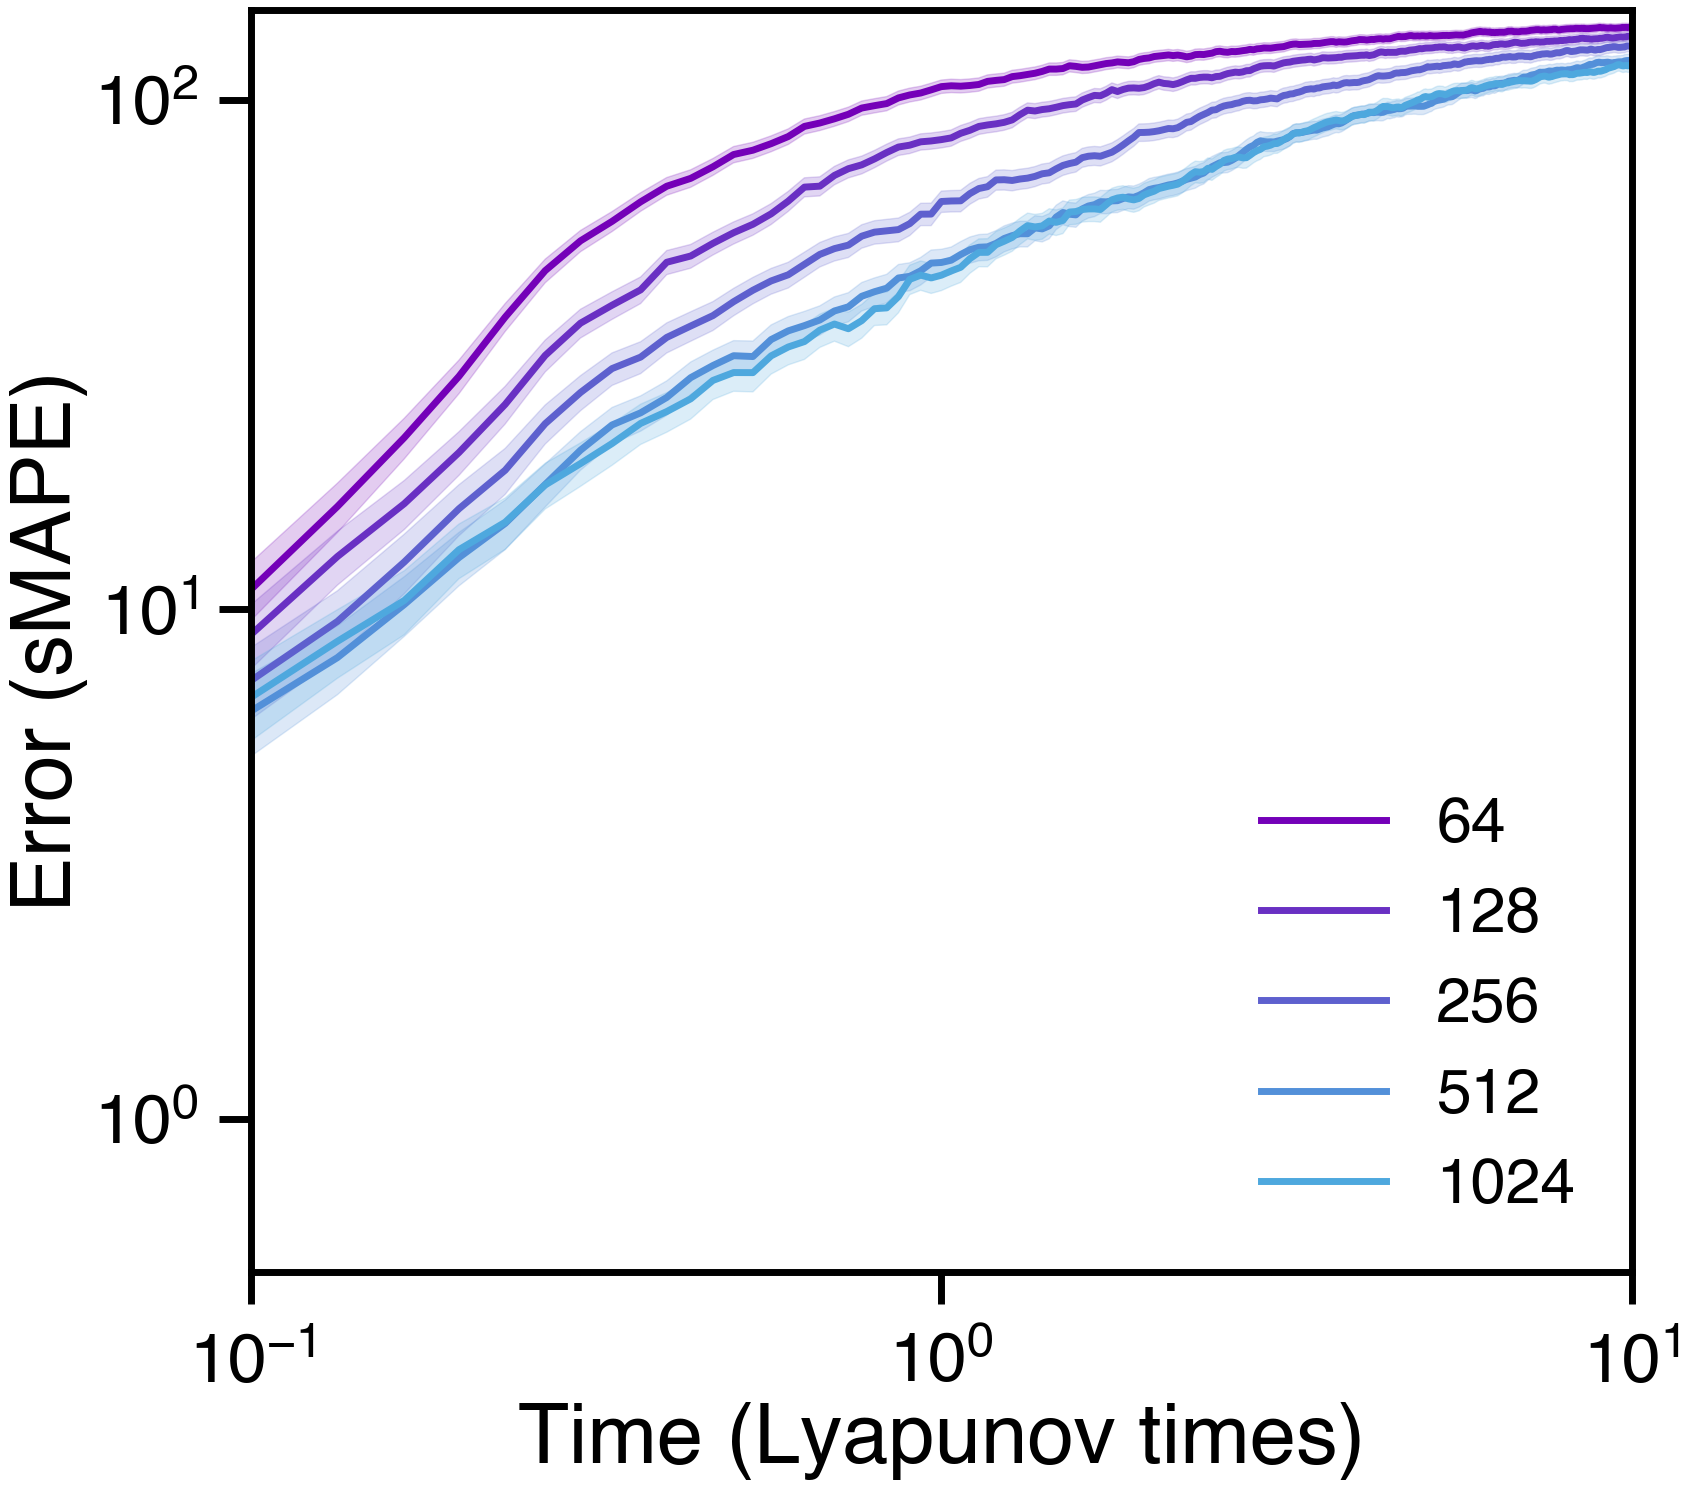

In [119]:
#import degas as dg
colors = ['#f94144', '#f3722c', '#f8961e', '#f9844a', '#f9c74f', '#90be6d', '#43aa8b', '#4d908e', '#577590', '#277da1']
colors = ["#7400b8","#6930c3","#5e60ce","#5390d9","#4ea8de","#48bfe3","#56cfe1","#64dfdf","#72efdd","#80ffdb"]

time = np.arange(1/granularity, (forecast_length+1)/granularity, 1/granularity)

# Plot Average VPT vs. Context Length for each equation
fig = plt.figure()
ax = fig.add_subplot(111)

for axis in ['bottom','left']:
  ax.spines[axis].set_linewidth(5)
for axis in ['top','right']:
  ax.spines[axis].set_linewidth(5)
  #ax.spines[axis].set_visible(False)

ax.get_xaxis().tick_bottom()
ax.get_yaxis().tick_left()

fig.set_size_inches(17,15)
plt.xticks(fontsize = 50)
plt.yticks(fontsize = 50)
plt.xlabel(r'Time (Lyapunov times)', fontname="Helvetica", fontsize = 60)
plt.ylabel(r'Error (sMAPE)', fontname="Helvetica", fontsize = 60)
  
for i, context_length in enumerate(context_lengths_chronos):
  smape_trjs = [median_smape[(equation_name, context_length)] for equation_name, ctx in median_smape.keys() if ctx == context_length]
  smape_trj = np.median(smape_trjs, axis=0)
  smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
  plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[i], label=context_length)
  ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[i])
  #dg.plot_err(smape_trj, smape_std/1.0, x=time, color=colors[i], label=context_length, zorder=10*i)

plt.xscale('log')
plt.yscale('log')

plt.xlim([.1, 10])
plt.ylim([.5, 150])

plt.legend(loc='lower right', frameon=False, prop={'size':45}, ncol=1)

plt.gca().tick_params(axis='y', pad=15, size=23, width=5)
plt.gca().tick_params(axis='x', pad=20, size=23, width=5)

fig.set_tight_layout(True)
plt.savefig(f'smape_rolling_chronos_normalized.pdf', bbox_inches='tight')

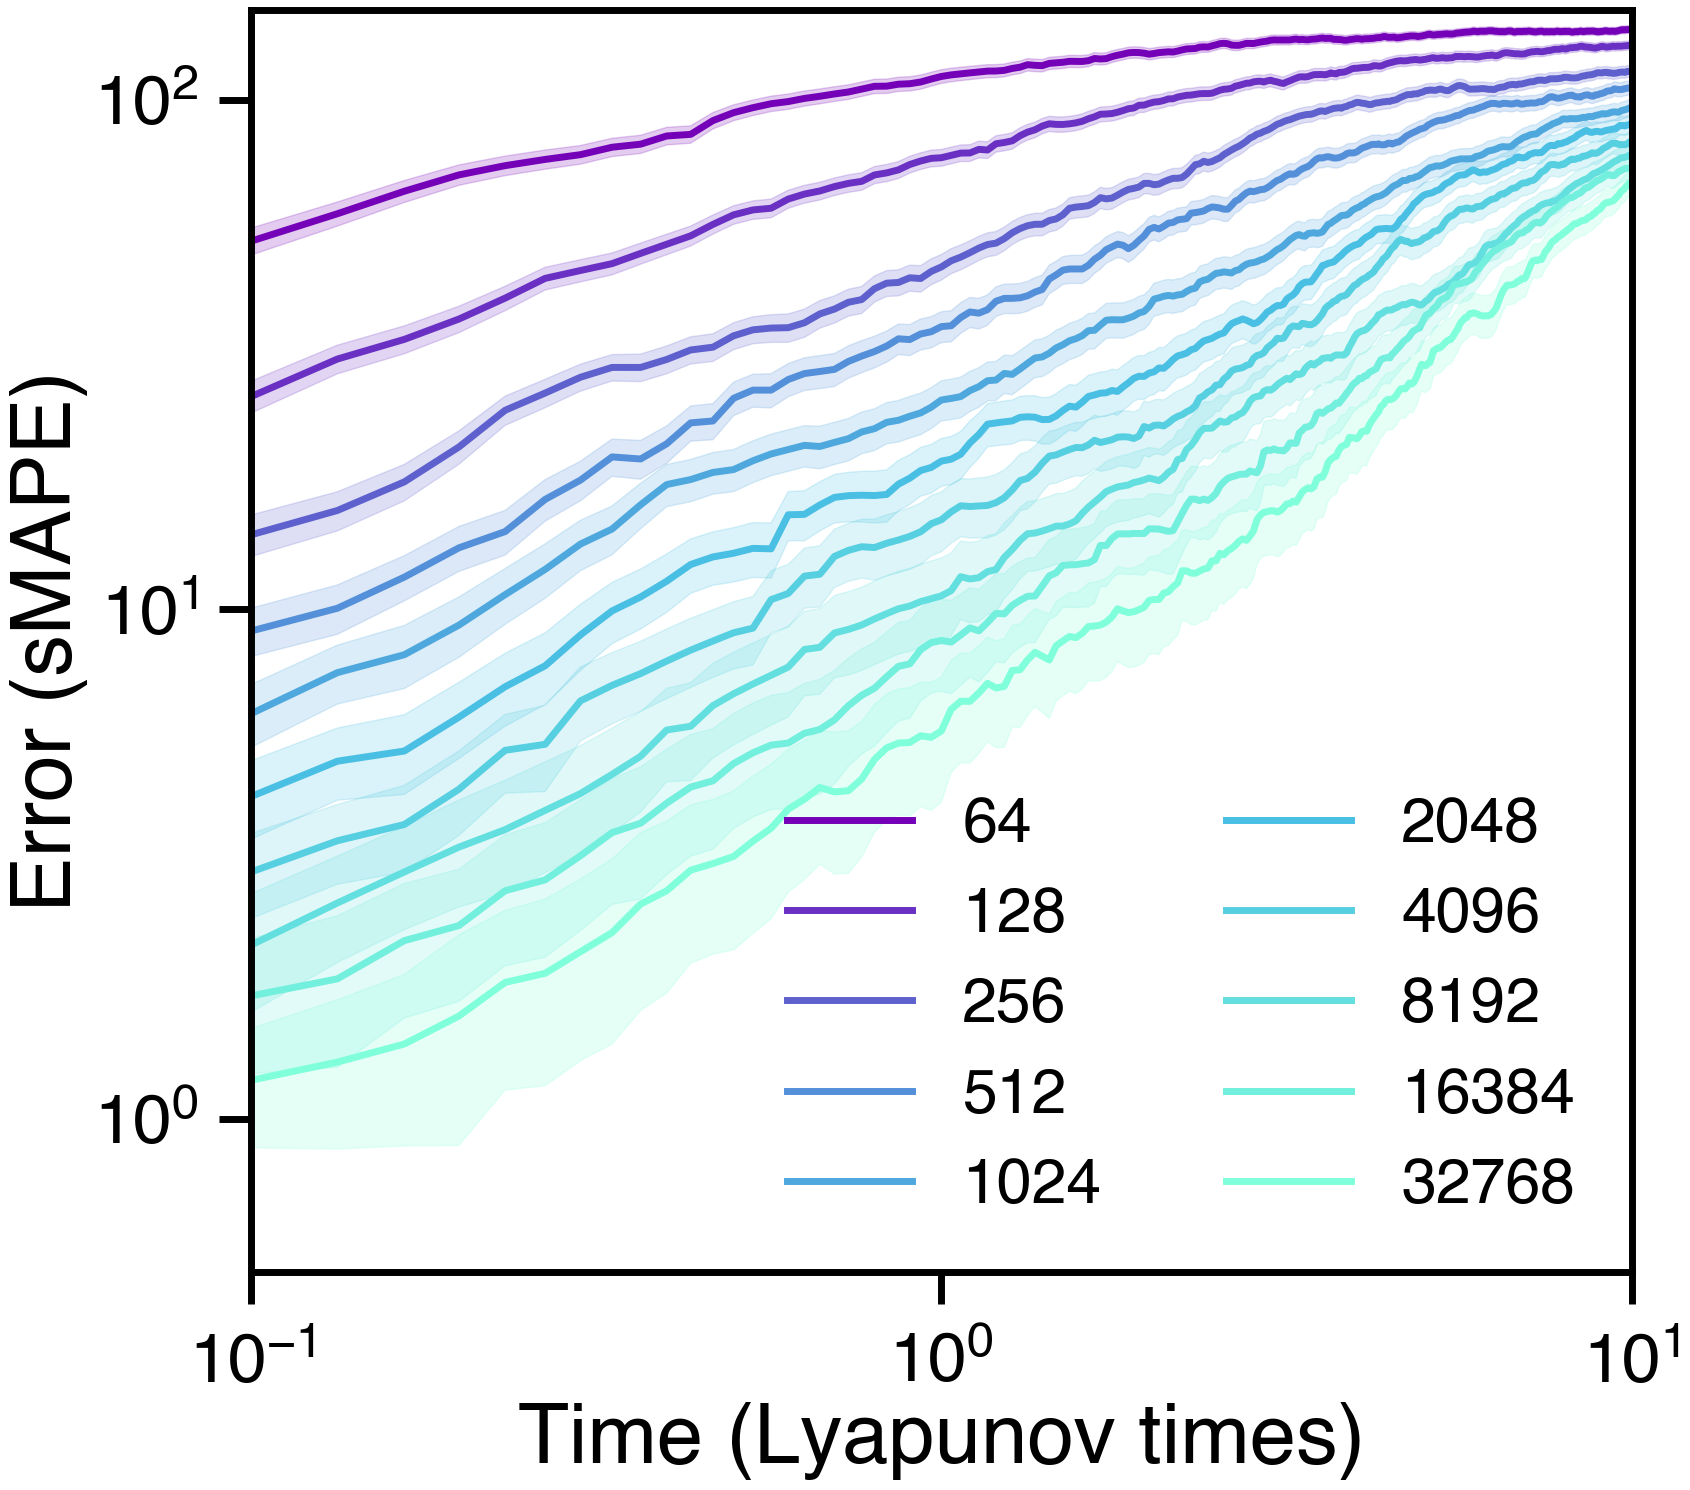

In [122]:
#import degas as dg
colors = ['#f94144', '#f3722c', '#f8961e', '#f9844a', '#f9c74f', '#90be6d', '#43aa8b', '#4d908e', '#577590', '#277da1']
colors = ["#7400b8","#6930c3","#5e60ce","#5390d9","#4ea8de","#48bfe3","#56cfe1","#64dfdf","#72efdd","#80ffdb"]

time = np.arange(1/granularity, (forecast_length+1)/granularity, 1/granularity)

# Plot Average VPT vs. Context Length for each equation
fig = plt.figure()
ax = fig.add_subplot(111)

for axis in ['bottom','left']:
  ax.spines[axis].set_linewidth(5)
for axis in ['top','right']:
  ax.spines[axis].set_linewidth(5)
  #ax.spines[axis].set_visible(False)

ax.get_xaxis().tick_bottom()
ax.get_yaxis().tick_left()

fig.set_size_inches(17,15)
plt.xticks(fontsize = 50)
plt.yticks(fontsize = 50)
plt.xlabel(r'Time (Lyapunov times)', fontname="Helvetica", fontsize = 60)
plt.ylabel(r'Error (sMAPE)', fontname="Helvetica", fontsize = 60)
  
for i, context_length in enumerate(context_lengths_parrot[:-1]):
  smape_trjs = [Parrot_median_smape[(equation_name, context_length)] for equation_name, ctx in Parrot_median_smape.keys() if ctx == context_length]
  smape_trj = np.median(smape_trjs, axis=0)
  smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
  plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[i], label=context_length)
  ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[i])
  #dg.plot_err(smape_trj, smape_std/1.0, x=time, color=colors[i], label=context_length, zorder=10*i)

plt.xscale('log')
plt.yscale('log')

plt.xlim([.1, 10])
plt.ylim([.5, 150])

plt.legend(loc='lower right', frameon=False, prop={'size':45}, ncol=2)

plt.gca().tick_params(axis='y', pad=15, size=23, width=5)
plt.gca().tick_params(axis='x', pad=20, size=23, width=5)

fig.set_tight_layout(True)
plt.savefig(f'smape_rolling_D=10_normalized.pdf', bbox_inches='tight')